### Hotel bookings, exploratory analysis
* structure of the training data and of the feed tables behind the models
* revenue management view of the two hotels: cancellations, lead time, seasonality, rates, occupancy
* one section per dashboard model: features, target, distributions, correlation and multicollinearity

#### How the training data was built
* synthetic booking stream from January 2014 to today, one row per booking made up to today
* every row is a real 2015 to 2017 booking of the same hotel and calendar month used as an atom, with its attributes augmented by small random changes; the outcome is a draw from a cancellation world model fit on the real bookings, never the atom's own outcome; non refundable bookings cancel at half the flexible rate as in the industry instead of the 99 percent of the source data, and a share of the cancellations are no shows
* the number of bookings per hotel and week follows the real weekly profile times the Eurostat level of Portugal hotel nights for the month
* the market mix follows Wikipedia attention per language six weeks before arrival, the euro exchange rates, holidays and the event table
* rates are the atom rate times the official monthly four star rate of the hotel's region relative to 2019 (Turismo de Portugal), bridged from 2015 to 2018 by the Eurostat accommodation price trend; a share of agency atoms become direct bookings so that direct and corporate reach a third of bookings by 2023; the hotel has 270 and 260 rooms and stops selling a stay date once the rooms expected to stay reach capacity plus a small overbooking buffer, and stays above 98 percent of capacity are turned away
* events flip outcomes of bookings on the books through a hazard and change lead times during their recovery
* outcomes are revealed when a booking leaves the books; rows with an outcome not revealed yet carry a missing outcome
* outcome analyses below use complete arrival cohorts only: arrivals at least 31 days before today, so every outcome is known and no month or year is partial

In [1]:
import os
import sys
import glob
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mutual_info_score
warnings.filterwarnings("ignore")

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT_DIR)

from app.models import context
from app.models import features

In [3]:
# paths, plot style and shared constants
PARQUET_DIR = os.path.join(ROOT_DIR, "data", "parquet")
BOOKINGS_PATH = os.path.join(PARQUET_DIR, "bookings.parquet")
WEATHER_PATH = os.path.join(PARQUET_DIR, "weather.parquet")
HOLIDAYS_PATH = os.path.join(PARQUET_DIR, "holidays.parquet")
PAGEVIEWS_PATH = os.path.join(PARQUET_DIR, "pageviews.parquet")
EUROSTAT_PATH = os.path.join(PARQUET_DIR, "eurostat.parquet")
LISTINGS_PATH = os.path.join(PARQUET_DIR, "airbnb_listings.parquet")
AVAILABILITY_PATH = os.path.join(PARQUET_DIR, "airbnb_availability.parquet")
REVIEWS_PATH = os.path.join(PARQUET_DIR, "airbnb_reviews_sample.parquet")
sns.set_theme(style="ticks")
pd.set_option("display.width", 220)
hotel_colors = {"City Hotel": "steelblue", "Resort Hotel": "darkcyan"}
capacity = {"City Hotel": 270, "Resort Hotel": 260}
hotels = ["City Hotel", "Resort Hotel"]
rng = np.random.default_rng(7)
clip_quantile = 0.995
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")

### Data overview
* the staged bookings table with typed dates, one row per booking made up to today
* column types, missing values, unique values and the numeric summary
* bookings, cancellations and rates per arrival year, bookings touched by a shock
* the feed tables used by the models: weather, holidays, Wikipedia pageviews, Eurostat nights, Airbnb listings and reviews

In [4]:
# load the staged bookings with typed dates
def load_bookings(path):
    frame = pd.read_parquet(path)
    for col in ["arrival_date", "booking_date", "checkout_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    return frame

In [5]:
# one row per column: type, filled and missing counts, unique values and an example value
def overview_table(frame):
    rows = []
    for col in frame.columns:
        values = frame[col]
        first = values.dropna().iloc[0] if values.notna().any() else None
        rows.append({"column": col, "dtype": str(values.dtype), "non_null": int(values.notna().sum()), "missing": int(values.isna().sum()), "missing_share": round(float(values.isna().mean()), 4), "unique": int(values.nunique()), "example": str(first)[:24]})
    return pd.DataFrame(rows)

In [6]:
# numeric summary of the frame, count, mean, spread and quantiles per column
def describe_numeric(frame):
    return frame.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

In [7]:
# shape, date range and missing cells of one feed table
def table_summary(name, frame, date_col):
    dates = pd.to_datetime(frame[date_col], errors="coerce")
    return {"table": name, "rows": len(frame), "columns": frame.shape[1], "from": str(dates.min())[:10], "to": str(dates.max())[:10], "missing_cells": int(frame.isna().sum().sum())}

In [8]:
# cancellation rate and booking counts per hotel
def cancellation_by_hotel(frame):
    out = frame.groupby("hotel").agg(bookings=("booking_id", "size"), cancel_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"), avg_lead=("lead_time", "mean"), avg_nights=("nights", "mean"))
    return out.round(3)

In [9]:
# bookings, cancel rate and mean rate per complete arrival year and hotel, the current year left out
def yearly_profile(frame):
    frame = frame[frame["arrival_date"].dt.year < today.year]
    out = frame.groupby(["hotel", frame["arrival_date"].dt.year]).agg(bookings=("booking_id", "size"), cancel_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"), avg_lead=("lead_time", "mean"))
    out.index.names = ["hotel", "year"]
    return out.round(3)

In [10]:
# bookings and cancel rate per arrival year per hotel
def plot_yearly(frame):
    yearly = yearly_profile(frame).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for hotel, part in yearly.groupby("hotel"):
        axes[0].plot(part["year"], part["bookings"], marker="o", color=hotel_colors[hotel], label=hotel)
        axes[1].plot(part["year"], part["cancel_rate"], marker="o", color=hotel_colors[hotel], label=hotel)
    axes[0].set_ylabel("bookings by arrival year")
    axes[1].set_ylabel("cancel rate")
    axes[1].set_ylim(0, 0.6)
    axes[0].legend()
    fig.suptitle("Bookings and cancellations by year")
    plt.tight_layout()
    plt.show()

In [11]:
# bookings whose outcome was flipped by an event shock, cancellations and no shows per event with the arrival window
def shock_table(frame):
    part = frame[frame["shock"] != ""]
    out = part.groupby("shock").agg(flipped=("booking_id", "size"), canceled=("reservation_status", lambda s: int((s == "Canceled").sum())), no_show=("reservation_status", lambda s: int((s == "No-Show").sum())), first_arrival=("arrival_date", "min"), last_arrival=("arrival_date", "max"))
    return out.sort_values("flipped", ascending=False)

In [12]:
bookings = load_bookings(BOOKINGS_PATH)
today = pd.Timestamp(datetime.date.today())
complete_until = today - pd.Timedelta(days=31)
complete = bookings[(bookings["arrival_date"] <= complete_until) & (bookings["outcome_known"] == True)].copy()
complete["is_canceled"] = complete["is_canceled"].astype(int)
print("rows " + str(len(bookings)) + ", columns " + str(bookings.shape[1]))
print("arrivals from " + str(bookings["arrival_date"].min().date()) + " to " + str(bookings["arrival_date"].max().date()))
print("bookings made from " + str(bookings["booking_date"].min().date()) + " to " + str(bookings["booking_date"].max().date()))
print("complete cohorts: arrivals up to " + str(complete_until.date()) + ", " + str(len(complete)) + " bookings with a known outcome")
print(overview_table(bookings).to_string(index=False))

rows 677730, columns 58
arrivals from 2014-01-06 to 2027-10-31
bookings made from 2012-02-07 to 2026-09-26
complete cohorts: arrivals up to 2026-08-26, 657083 bookings with a known outcome


                        column          dtype  non_null  missing  missing_share  unique             example
                    booking_id          int64    677730        0         0.0000  677730              366101
                         hotel            str    677730        0         0.0000       2          City Hotel
                     lead_time          int64    677730        0         0.0000     700                  35
                  arrival_date  datetime64[s]    677730        0         0.0000    5047 2021-09-03 00:00:00
       stays_in_weekend_nights          int64    677730        0         0.0000      20                   2
          stays_in_week_nights          int64    677730        0         0.0000      42                   2
                        nights          int64    677730        0         0.0000      51                   4
                        adults          int64    677730        0         0.0000      13                   2
                      childr

                                   count      mean       std   min       1%       25%       50%        75%        99%        max
lead_time                       677730.0    102.30    107.81  0.00     0.00     19.00     67.00     152.00     460.00     700.00
stays_in_weekend_nights         677730.0      1.03      1.01  0.00     0.00      0.00      1.00       2.00       4.00      20.00
stays_in_week_nights            677730.0      2.42      1.98  0.00     0.00      1.00      2.00       3.00      10.00      49.00
nights                          677730.0      3.45      2.59  1.00     1.00      2.00      3.00       4.00      14.00      69.00
adults                          677730.0      1.86      0.61  1.00     1.00      2.00      2.00       2.00       3.00      55.00
children                        677730.0      0.10      0.38  0.00     0.00      0.00      0.00       0.00       2.00      10.00
babies                          677730.0      0.01      0.10  0.00     0.00      0.00      0.00  

                   bookings  cancel_rate  avg_adr  avg_lead
hotel        year                                          
City Hotel   2014     29715        0.275   96.231   111.326
             2015     32867        0.277  100.328   110.113
             2016     35458        0.279  102.911   110.597
             2017     37413        0.288  111.206   115.170
             2018     37632        0.277  121.723   112.902
             2019     37634        0.283  124.924   112.654
             2020     17573        0.348   98.173    81.624
             2021     21931        0.281   95.335    53.710
             2022     36370        0.255  132.093    76.263
             2023     39581        0.272  151.656   109.313
             2024     40001        0.273  150.243   116.946
             2025     40087        0.282  163.480   117.385
Resort Hotel 2014     15224        0.232   81.777    94.972
             2015     16108        0.236   86.090    91.629
             2016     17986        0.231

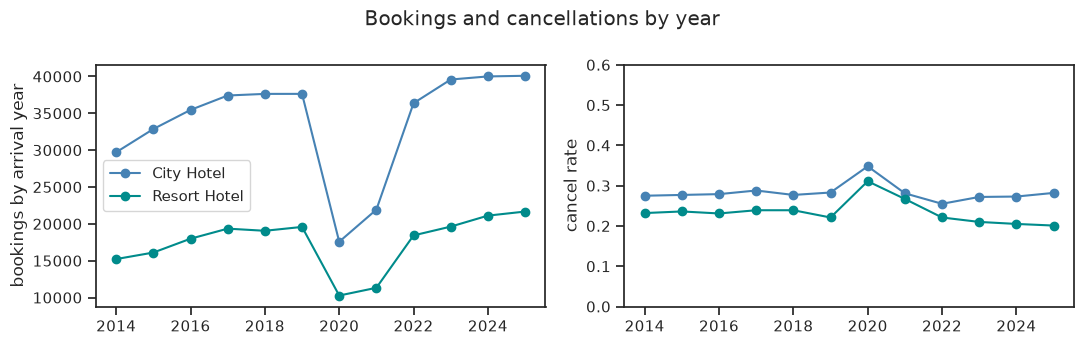

bookings whose outcome was flipped by a shock 4843 of 657083
                       flipped  canceled  no_show first_arrival last_arrival
shock                                                                       
covid_second_wave         1629       736      893    2020-10-14   2021-04-30
covid_first_wave          1385      1105      280    2020-02-16   2020-05-31
covid_omicron              575       333      242    2021-11-17   2022-01-31
covid_green_list_2021      483       120      363    2021-04-26   2021-08-31
covid_summer_2020          364        33      331    2020-06-02   2020-10-30
storm_leslie_2018           92        73       19    2018-10-01   2018-10-15
monchique_fire_2018         71        71        0    2018-07-26   2018-08-12
blackout_2025               63        25       38    2025-04-22   2025-04-29
fires_october_2017          56        56        0    2017-10-11   2017-10-31
fires_june_2017             43        43        0    2017-06-10   2017-06-30
strike_june_202

In [13]:
print(describe_numeric(bookings.select_dtypes("number").drop(columns=["booking_id", "source_booking_id"], errors="ignore")).to_string())
print(cancellation_by_hotel(complete).to_string())
print(yearly_profile(complete).to_string())
plot_yearly(complete)
print("bookings whose outcome was flipped by a shock " + str(int((complete["shock"] != "").sum())) + " of " + str(len(complete)))
print(shock_table(complete).to_string())

In [14]:
feeds = [("weather", WEATHER_PATH, "date"), ("holidays", HOLIDAYS_PATH, "date"), ("pageviews", PAGEVIEWS_PATH, "date"), ("eurostat", EUROSTAT_PATH, "month"), ("airbnb_listings", LISTINGS_PATH, "host_since"), ("airbnb_reviews_sample", REVIEWS_PATH, "date")]
print(pd.DataFrame([table_summary(name, pd.read_parquet(path), col) for name, path, col in feeds]).to_string(index=False))

                table  rows  columns       from         to  missing_cells
              weather  8328        9 2014-01-01 2026-10-11              0
             holidays 13937        5 2014-01-01 2028-01-11              0
            pageviews 49246        5 2015-07-01 2026-09-25              0
             eurostat  1008        4 2014-01-01 2026-06-01              0
      airbnb_listings 24876       35        NaT        NaT          86727
airbnb_reviews_sample 67956        4 2025-01-01 2026-07-01              0


### Diagnostics used in every model section
* distributions: histogram per numeric feature clipped at the 99.5th percentile, bar of zeros and ones for binary features, top levels for categorical features
* target: bar of class counts for a categorical target, histogram for a continuous target
* correlation with the target, correlation matrix between features, pairwise scatter of the strongest features
* variance inflation factor per numeric feature: the r2 of the feature regressed on all others, exact when the feature is a linear identity of others, then again without the redundant members

In [15]:
# true when a series holds only zeros and ones
def is_binary(values):
    return set(pd.unique(values.dropna())) <= {0, 1}

In [16]:
# bar of class counts for a categorical target with count and share labels
def plot_target_bar(values, name):
    counts = values.value_counts().sort_index()
    share = counts / counts.sum()
    labels = [str(int(n)) + ", " + str(round(100 * s, 1)) + " percent" for n, s in zip(counts.values, share.values)]
    plt.figure(figsize=(4.5, 3.2))
    bars = plt.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="black", linewidth=0.5)
    plt.bar_label(bars, labels=labels, fontsize=9)
    plt.ylabel("rows")
    plt.title(name)
    plt.show()

In [17]:
# histogram per numeric feature clipped at the upper quantile, bar of zeros and ones for binary features
def plot_histograms(frame, cols, ncols=5, bins=40):
    cols = [c for c in cols if c in frame.columns]
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 2.7 * nrows))
    for ax, col in zip(np.ravel(axes), cols):
        values = pd.to_numeric(frame[col], errors="coerce").dropna()
        if is_binary(values):
            counts = values.value_counts().reindex([0, 1]).fillna(0)
            ax.bar(["0", "1"], counts.values, color=["gray", "steelblue"], edgecolor="black", linewidth=0.5)
        else:
            ax.hist(values.clip(upper=values.quantile(clip_quantile)), bins=bins, color="steelblue", edgecolor="black", linewidth=0.3)
        ax.set_title(col, fontsize=10)
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [18]:
# horizontal bars of the most frequent levels per categorical feature, the rest grouped as other
def plot_category_bars(frame, cols, top=10, ncols=3):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 2.9 * nrows))
    for ax, col in zip(np.ravel(axes), cols):
        counts = frame[col].astype(str).value_counts()
        head = counts.head(top)
        if len(counts) > top:
            head = pd.concat([head, pd.Series({"other, " + str(len(counts) - top) + " levels": counts.iloc[top:].sum()})])
        ax.barh(head.index[::-1], head.values[::-1], color="steelblue", edgecolor="black", linewidth=0.3)
        ax.set_title(col + ", " + str(len(counts)) + " levels", fontsize=10)
        ax.tick_params(axis="y", labelsize=8)
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [19]:
# histogram of one column per hotel
def plot_by_hotel(frame, col, bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
    for ax, hotel in zip(axes, hotels):
        values = frame.loc[frame["hotel"] == hotel, col]
        ax.hist(values, bins=bins, color=hotel_colors[hotel], edgecolor="black", linewidth=0.3)
        ax.set_title(hotel, fontsize=10)
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

In [20]:
# pearson correlation of every numeric feature with the target, sorted by absolute value
def target_correlation(frame, cols, target):
    x = frame[cols].apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(frame[target], errors="coerce")
    corr = x.corrwith(y).dropna().round(3)
    out = corr.reindex(corr.abs().sort_values(ascending=False).index)
    return out.rename("pearson_with_" + target).to_frame()

In [21]:
# correlation matrix heatmap between numeric features, annotated when the matrix is small
def plot_correlation(frame, cols):
    corr = frame[cols].apply(pd.to_numeric, errors="coerce").corr()
    size = max(6, 0.38 * len(cols))
    plt.figure(figsize=(size, size * 0.85))
    sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=len(cols) <= 16, fmt=".2f", annot_kws={"size": 8}, square=True, cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
    plt.tick_params(axis="both", labelsize=8)
    plt.title("Correlation matrix")
    plt.show()
    return corr

In [22]:
# feature pairs with the largest absolute correlation, the upper triangle of the matrix without the masked cells
def top_pairs(corr, n=12):
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack(future_stack=True).dropna().rename("pearson").reset_index()
    pairs.columns = ["feature_a", "feature_b", "pearson"]
    pairs = pairs.reindex(pairs["pearson"].abs().sort_values(ascending=False).index)
    return pairs.head(n).round(3)

In [23]:
# pairwise scatter of a few features on a sample of rows
def plot_pairs(frame, cols, n=3000):
    sample = frame[cols].apply(pd.to_numeric, errors="coerce").dropna()
    sample = sample.sample(min(n, len(sample)), random_state=7)
    grid = sns.pairplot(sample, corner=True, diag_kind="hist", height=1.9, plot_kws={"alpha": 0.35, "s": 8, "color": "steelblue"}, diag_kws={"color": "steelblue"})
    grid.figure.suptitle("Pairwise scatter", y=1.01)
    plt.show()

In [24]:
# variance inflation factor per numeric feature from the r2 of the feature regressed on all others, rows with missing values and constant features left out, quiet skips the row counts
def vif_table(frame, cols, quiet=False):
    x = frame[cols].apply(pd.to_numeric, errors="coerce").dropna()
    constant = [c for c in x.columns if x[c].std() == 0]
    x = x.drop(columns=constant)
    z = ((x - x.mean()) / x.std()).values
    rows = []
    for j, col in enumerate(x.columns):
        others = np.delete(z, j, axis=1)
        beta = np.linalg.lstsq(others, z[:, j], rcond=None)[0]
        r2 = 1 - np.var(z[:, j] - others @ beta)
        vif = np.inf if r2 >= 0.9999 else 1 / (1 - r2)
        partners = [c for c, b in zip(np.delete(x.columns.values, j), beta) if abs(b) > 0.05]
        rows.append({"feature": col, "r2_on_others": round(float(r2), 4), "vif": round(float(vif), 2), "identity_with": ", ".join(partners) if r2 >= 0.9999 else ""})
    out = pd.DataFrame(rows).sort_values("vif", ascending=False)
    out["level"] = np.select([np.isinf(out["vif"]), out["vif"] >= 10, out["vif"] >= 5], ["exact", "high", "moderate"], "low")
    if not quiet:
        print("rows used " + str(len(x)) + " of " + str(len(frame)))
    if constant and not quiet:
        print("constant features left out of the vif table: " + ", ".join(constant))
    return out

In [25]:
# the vif table after dropping the features that are exact linear identities of others, one member per identity kept
def vif_without_identities(frame, cols):
    first = vif_table(frame, cols, quiet=True)
    exact = first[first["level"] == "exact"]["feature"].tolist()
    dropped = []
    for feature in exact:
        remaining = [c for c in cols if c not in dropped]
        check = vif_table(frame, remaining, quiet=True)
        if check.loc[check["feature"] == feature, "level"].item() == "exact":
            dropped.append(feature)
    if dropped:
        print("features dropped as identities of others: " + ", ".join(dropped))
    return vif_table(frame, [c for c in cols if c not in dropped])

In [26]:
# univariate power of numeric features against a binary target, roc auc of the raw value oriented above 0.5
def numeric_power(frame, cols, target):
    rows = []
    y = frame[target].values
    for col in cols:
        x = pd.to_numeric(frame[col], errors="coerce").fillna(0).values
        if x.std() == 0:
            continue
        auc = roc_auc_score(y, x)
        rows.append({"feature": col, "auc": round(max(auc, 1 - auc), 4), "direction": "higher means more" if auc >= 0.5 else "higher means less", "corr": round(float(np.corrcoef(x, y)[0, 1]), 3)})
    return pd.DataFrame(rows).sort_values("auc", ascending=False)

In [27]:
# power of categorical features against a binary target, mutual information and the spread of target rates across levels
def categorical_power(frame, cols, target):
    rows = []
    y = frame[target].values
    for col in cols:
        x = frame[col].astype(str).values
        rates = frame.groupby(x)[target].agg(["mean", "size"])
        rates = rates[rates["size"] >= 100]
        rows.append({"feature": col, "mutual_info": round(float(mutual_info_score(x, y)), 4), "levels": int(rates.shape[0]), "rate_min": round(float(rates["mean"].min()), 3), "rate_max": round(float(rates["mean"].max()), 3)})
    return pd.DataFrame(rows).sort_values("mutual_info", ascending=False)

In [28]:
# target rate by decile of a numeric feature
def plot_rate_by_decile(frame, cols, target):
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3.3))
    for ax, col in zip(np.atleast_1d(axes), cols):
        x = pd.to_numeric(frame[col], errors="coerce").fillna(0)
        buckets = pd.qcut(x.rank(method="first"), 10, labels=False)
        curve = frame.groupby(buckets)[target].mean()
        ax.plot(curve.index + 1, curve.values, marker="o", color="red")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("decile")
        ax.set_ylim(0, 1)
    np.atleast_1d(axes)[0].set_ylabel(target + " rate")
    plt.tight_layout()
    plt.show()

### Revenue management view
* cancellations by segment, channel, deposit, country and lead time
* arrivals, cancellations and rates by month, occupancy by week and weekday
* extreme values of the numeric fields

In [29]:
# cancellation rate by a categorical column, sorted by volume
def cancellation_by(frame, col, min_count=200):
    out = frame.groupby(col).agg(bookings=("is_canceled", "size"), cancel_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"))
    out = out[out["bookings"] >= min_count].sort_values("bookings", ascending=False)
    return out.round(3)

In [30]:
# cancellation rate by lead time bucket
def cancellation_by_lead(frame):
    edges = [-1, 0, 7, 14, 30, 60, 90, 180, 365, 1000]
    labels = ["0", "1-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "365+"]
    bucket = pd.cut(frame["lead_time"], bins=edges, labels=labels)
    out = frame.groupby(bucket, observed=True).agg(bookings=("is_canceled", "size"), cancel_rate=("is_canceled", "mean"))
    return out.round(3)

In [31]:
# monthly arrivals and cancellation rate per hotel
def plot_monthly(frame):
    monthly = frame.groupby(["hotel", frame["arrival_date"].dt.to_period("M")]).agg(bookings=("is_canceled", "size"), cancel_rate=("is_canceled", "mean")).reset_index()
    monthly["month"] = monthly["arrival_date"].dt.to_timestamp()
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for hotel, part in monthly.groupby("hotel"):
        axes[0].plot(part["month"], part["bookings"], color=hotel_colors[hotel], label=hotel)
        axes[1].plot(part["month"], part["cancel_rate"], color=hotel_colors[hotel], label=hotel)
    axes[0].set_ylabel("bookings by arrival month")
    axes[1].set_ylabel("cancel rate")
    axes[0].set_title("Arrivals and cancellations by month")
    axes[0].legend()
    plt.show()

In [32]:
# distribution of lead time by outcome
def plot_lead_time(frame):
    plt.figure(figsize=(9, 4))
    bins = np.arange(0, 400, 10)
    plt.hist(frame.loc[frame["is_canceled"] == 0, "lead_time"], bins=bins, color="steelblue", alpha=0.7, label="stayed")
    plt.hist(frame.loc[frame["is_canceled"] == 1, "lead_time"], bins=bins, color="red", alpha=0.6, label="canceled")
    plt.xlabel("lead time in days")
    plt.ylabel("bookings")
    plt.title("Lead time by outcome")
    plt.legend()
    plt.show()

In [33]:
# average daily rate by arrival month per hotel, stayed bookings only
def plot_adr(frame):
    stayed = frame[(frame["is_canceled"] == 0) & (frame["adr"] > 0) & (frame["adr"] < 1000)]
    monthly = stayed.groupby(["hotel", stayed["arrival_date"].dt.to_period("M")])["adr"].mean().reset_index()
    monthly["month"] = monthly["arrival_date"].dt.to_timestamp()
    plt.figure(figsize=(10, 4))
    for hotel, part in monthly.groupby("hotel"):
        plt.plot(part["month"], part["adr"], color=hotel_colors[hotel], label=hotel)
    plt.ylabel("average daily rate")
    plt.title("ADR by arrival month")
    plt.legend()
    plt.show()

In [34]:
# one row per stay night of every booking with the dates it entered and left the books
def stay_nights(frame):
    part = frame[frame["nights"] > 0]
    nights = part.loc[part.index.repeat(part["nights"]), ["hotel", "arrival_date", "booking_date", "leave_books_date", "is_canceled", "adr"]].copy()
    nights["offset"] = nights.groupby(level=0).cumcount()
    nights["stay_date"] = nights["arrival_date"] + pd.to_timedelta(nights["offset"], unit="D")
    return nights.reset_index(drop=True)

In [35]:
# realised rooms and occupancy per stay date per hotel from stayed nights
def occupancy_series(nights, capacity):
    rooms = nights[nights["is_canceled"] == 0].groupby(["hotel", "stay_date"]).size().rename("rooms").reset_index()
    rooms["occupancy"] = rooms["rooms"] / rooms["hotel"].map(capacity)
    return rooms

In [36]:
# weekly occupancy plot per hotel
def plot_occupancy(rooms):
    weekly = rooms.set_index("stay_date").groupby("hotel")["occupancy"].resample("W").mean().reset_index()
    plt.figure(figsize=(10, 4))
    for hotel, part in weekly.groupby("hotel"):
        plt.plot(part["stay_date"], part["occupancy"], color=hotel_colors[hotel], label=hotel)
    plt.ylim(0, 1)
    plt.ylabel("occupancy")
    plt.title("Weekly occupancy")
    plt.legend()
    plt.show()

In [37]:
# day of week profile of occupancy and adr
def weekday_profile(frame, rooms):
    occ = rooms.groupby([rooms["hotel"], rooms["stay_date"].dt.dayofweek])["occupancy"].mean().unstack(0).round(3)
    stayed = frame[(frame["is_canceled"] == 0) & (frame["adr"] > 0)]
    adr = stayed.groupby(["hotel", stayed["arrival_date"].dt.dayofweek])["adr"].mean().unstack(0).round(1)
    occ.index = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
    adr.index = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
    return occ, adr

In [38]:
# table of extreme values per numeric field with the count outside a chosen range
def outlier_table(frame):
    bounds = {"adr": (0, 500), "lead_time": (0, 500), "nights": (1, 14), "adults": (1, 4), "children": (0, 3), "babies": (0, 1), "days_in_waiting_list": (0, 100), "booking_changes": (0, 5)}
    rows = []
    for col, (lo, hi) in bounds.items():
        rows.append({"field": col, "min": frame[col].min(), "p99": round(float(frame[col].quantile(0.99)), 1), "max": frame[col].max(), "below_" + str(lo): int((frame[col] < lo).sum()), "above_" + str(hi): int((frame[col] > hi).sum())})
    return pd.DataFrame(rows)

cancellation by market_segment
                bookings  cancel_rate  avg_adr
market_segment                                
Online TA         261797        0.388  136.489
Direct            126362        0.160  141.257
Offline TA/TO     117968        0.174  102.998
Groups            116420        0.211   98.332
Corporate          29821        0.158   82.390
Complementary       3858        0.152    4.098
Aviation             847        0.302  116.210
cancellation by distribution_channel
                      bookings  cancel_rate  avg_adr
distribution_channel                                
TA/TO                   480865        0.299  120.404
Direct                  138269        0.160  135.104
Corporate                37007        0.168   82.127
GDS                        919        0.244  143.446
cancellation by deposit_type


              bookings  cancel_rate  avg_adr
deposit_type                                
No Deposit      566540        0.281  123.339
Non Refund       89523        0.144  109.235
Refundable        1020        0.195   94.250
cancellation by customer_type
                 bookings  cancel_rate  avg_adr
customer_type                                  
Transient          491961        0.277  127.078
Transient-Party    139579        0.223  104.288
Contract            22349        0.206  105.838
Group                3194        0.117   97.709
cancellation by country
         bookings  cancel_rate  avg_adr
country                                
PRT        276756        0.316  110.163
GBR         78442        0.185  119.837
FRA         47254        0.182  128.573
ESP         43195        0.222  138.160
DEU         32750        0.167  122.763
IRL         21787        0.233  121.628
ITA         16048        0.318  132.202
USA         12777        0.242  152.866
BRA         11871        0.356  1

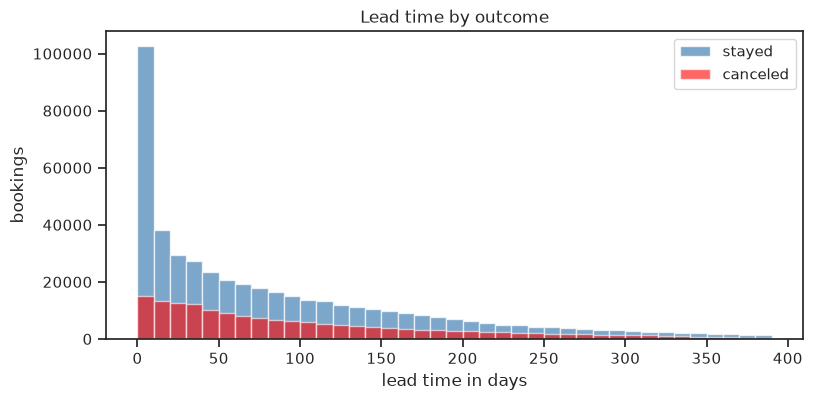

In [39]:
for col in ["market_segment", "distribution_channel", "deposit_type", "customer_type", "country"]:
    print("cancellation by " + col)
    print(cancellation_by(complete, col).head(10).to_string())
print(cancellation_by_lead(complete).to_string())
plot_lead_time(complete)

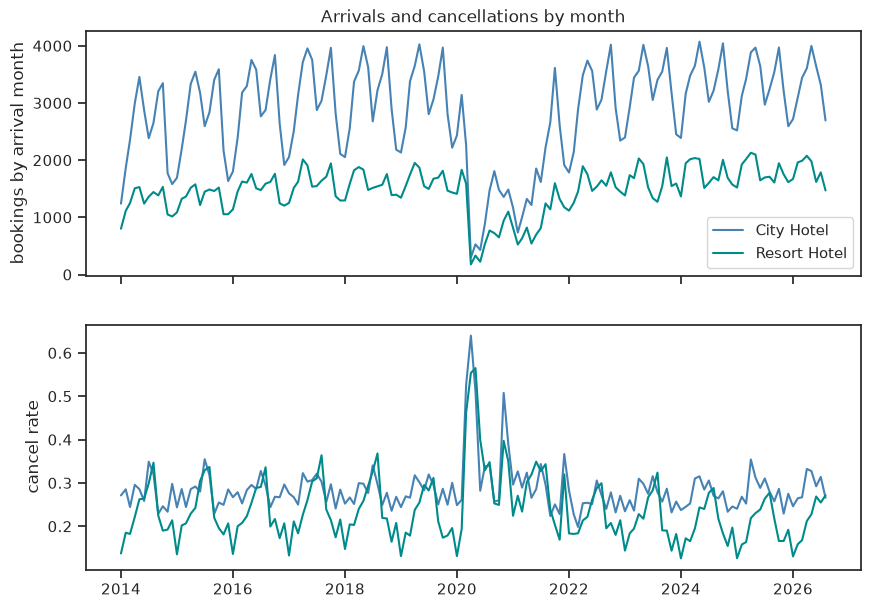

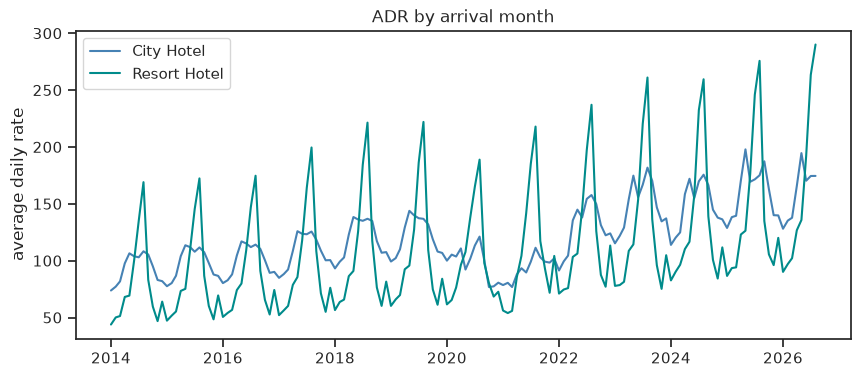

In [40]:
plot_monthly(complete)
plot_adr(complete)

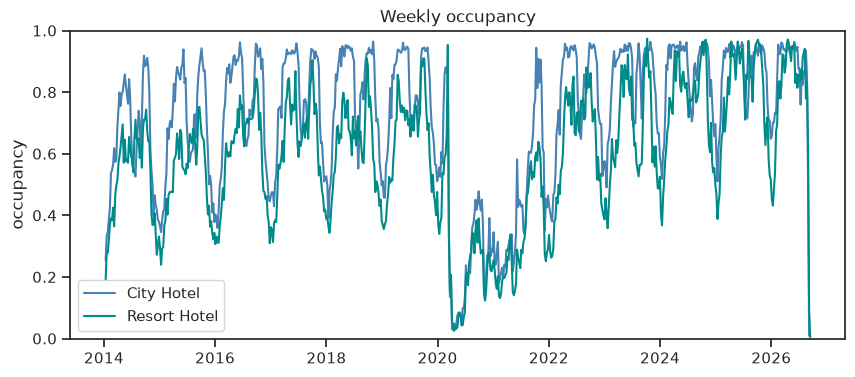

occupancy by weekday
hotel  City Hotel  Resort Hotel
mon         0.718         0.610
tue         0.677         0.587
wed         0.684         0.570
thu         0.720         0.588
fri         0.772         0.588
sat         0.757         0.618
sun         0.708         0.597
adr by arrival weekday
hotel  City Hotel  Resort Hotel
mon         127.0         108.1
tue         127.3         109.0
wed         125.7         109.9
thu         124.8         107.8
fri         124.1         106.8
sat         125.3         107.7
sun         127.5         107.9


In [41]:
nights = stay_nights(complete)
rooms = occupancy_series(nights, capacity)
plot_occupancy(rooms)
occ, adr = weekday_profile(complete, rooms)
print("occupancy by weekday")
print(occ.to_string())
print("adr by arrival weekday")
print(adr.to_string())

numeric fields clipped at the 0.995 quantile for the histograms


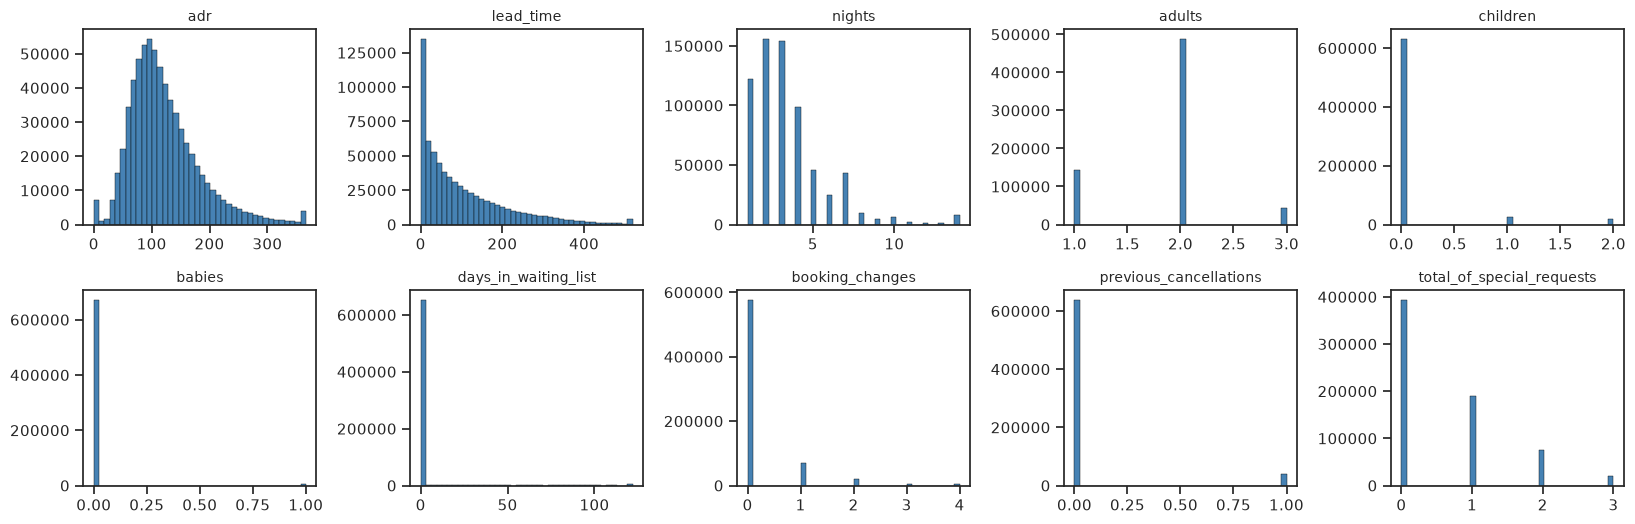

               field  min   p99   max  below_0  above_500  below_1  above_14  above_4  above_3  above_1  above_100  above_5
                 adr  0.0 330.3 744.6      0.0      286.0      NaN       NaN      NaN      NaN      NaN        NaN      NaN
           lead_time  0.0 460.0 700.0      0.0     4191.0      NaN       NaN      NaN      NaN      NaN        NaN      NaN
              nights  1.0  14.0  69.0      NaN        NaN      0.0    3176.0      NaN      NaN      NaN        NaN      NaN
              adults  1.0   3.0  55.0      NaN        NaN      0.0       NaN    107.0      NaN      NaN        NaN      NaN
            children  0.0   2.0  10.0      0.0        NaN      NaN       NaN      NaN      6.0      NaN        NaN      NaN
              babies  0.0   0.0  10.0      0.0        NaN      NaN       NaN      NaN      NaN    106.0        NaN      NaN
days_in_waiting_list  0.0  87.0 391.0      0.0        NaN      NaN       NaN      NaN      NaN      NaN     4857.0      NaN
     boo

In [42]:
print("numeric fields clipped at the " + str(clip_quantile) + " quantile for the histograms")
plot_histograms(bookings, ["adr", "lead_time", "nights", "adults", "children", "babies", "days_in_waiting_list", "booking_changes", "previous_cancellations", "total_of_special_requests"], ncols=5)
print(outlier_table(bookings).to_string(index=False))

### Cancellation model
* target: is_canceled, one row per booking observed at one random date between booking and departure from the books
* features: the feature list saved with the champion artifact, the gain pruned set of the experiments notebook, split into its categorical and numeric members
* bookings with a rate outside 0 to 1000 left out, as in the training notebook

In [43]:
# feature list of the champion cancellation model from its metrics file, the full feature module when no champion metrics exist
def champion_features():
    paths = glob.glob(os.path.join(MODELS_DIR, "cancellation_v*_metrics.json"))
    for name in sorted(paths, key=lambda s: int(s.split("_v")[1].split("_")[0]), reverse=True):
        with open(name) as f:
            m = json.load(f)
        if m.get("feature_list"):
            return m["feature_list"]
    return features.feature_names()

In [44]:
# feature matrix of the cancellation model, every booking with a known outcome observed once at a random date between booking and departure with the context features and the learned levels
def cancellation_frame(frame, weather, holidays):
    out = frame[(frame["adr"] >= 0) & (frame["adr"] < 1000) & (frame["outcome_known"] == True)].copy()
    out["is_canceled"] = out["is_canceled"].astype(int)
    span = (out["leave_books_date"].clip(upper=out["arrival_date"]) - out["booking_date"]).dt.days.clip(lower=0)
    offset = np.floor(rng.random(len(out)) * (span.values + 1))
    out["as_of"] = out["booking_date"] + pd.to_timedelta(offset, unit="D")
    out = context.add_context(out, weather, holidays)
    levels = features.fit_levels(out)
    x = features.transform(out, levels)
    x["is_canceled"] = out["is_canceled"].values
    return x

rows 663858, numeric features 39, categorical features 10
features left out of the champion: persona, stays_in_weekend_nights, adults, children, babies, is_repeated_guest, arrival_dow, booking_dow, has_company, has_agent, stay_home_holidays, stay_home_school_share, stay_pt_holidays, arrival_near_pt_holiday, same_day_clones, total_guests, weekend_share, family, party_size, arrival_weekend, adr_zero, long_lead, agent_new, company_prior_rate, company_prior_n, repeat_direct


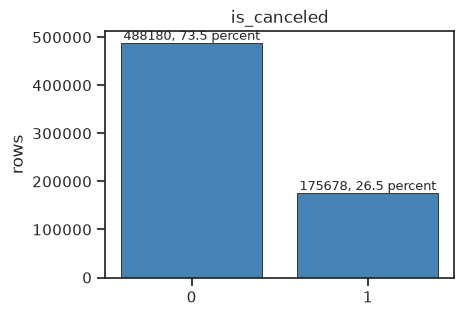

In [45]:
weather = pd.read_parquet(WEATHER_PATH)
holidays = pd.read_parquet(HOLIDAYS_PATH)
cancel_features = champion_features()
cancel_categorical = [f for f in cancel_features if f in features.categorical_columns]
cancel_numeric = [f for f in cancel_features if f not in features.categorical_columns]
x_cancel = cancellation_frame(bookings, weather, holidays)[cancel_features + ["is_canceled"]]
print("rows " + str(len(x_cancel)) + ", numeric features " + str(len(cancel_numeric)) + ", categorical features " + str(len(cancel_categorical)))
print("features left out of the champion: " + ", ".join(f for f in features.feature_names() if f not in cancel_features))
plot_target_bar(x_cancel["is_canceled"], "is_canceled")

numeric features clipped at the 0.995 quantile for the histograms


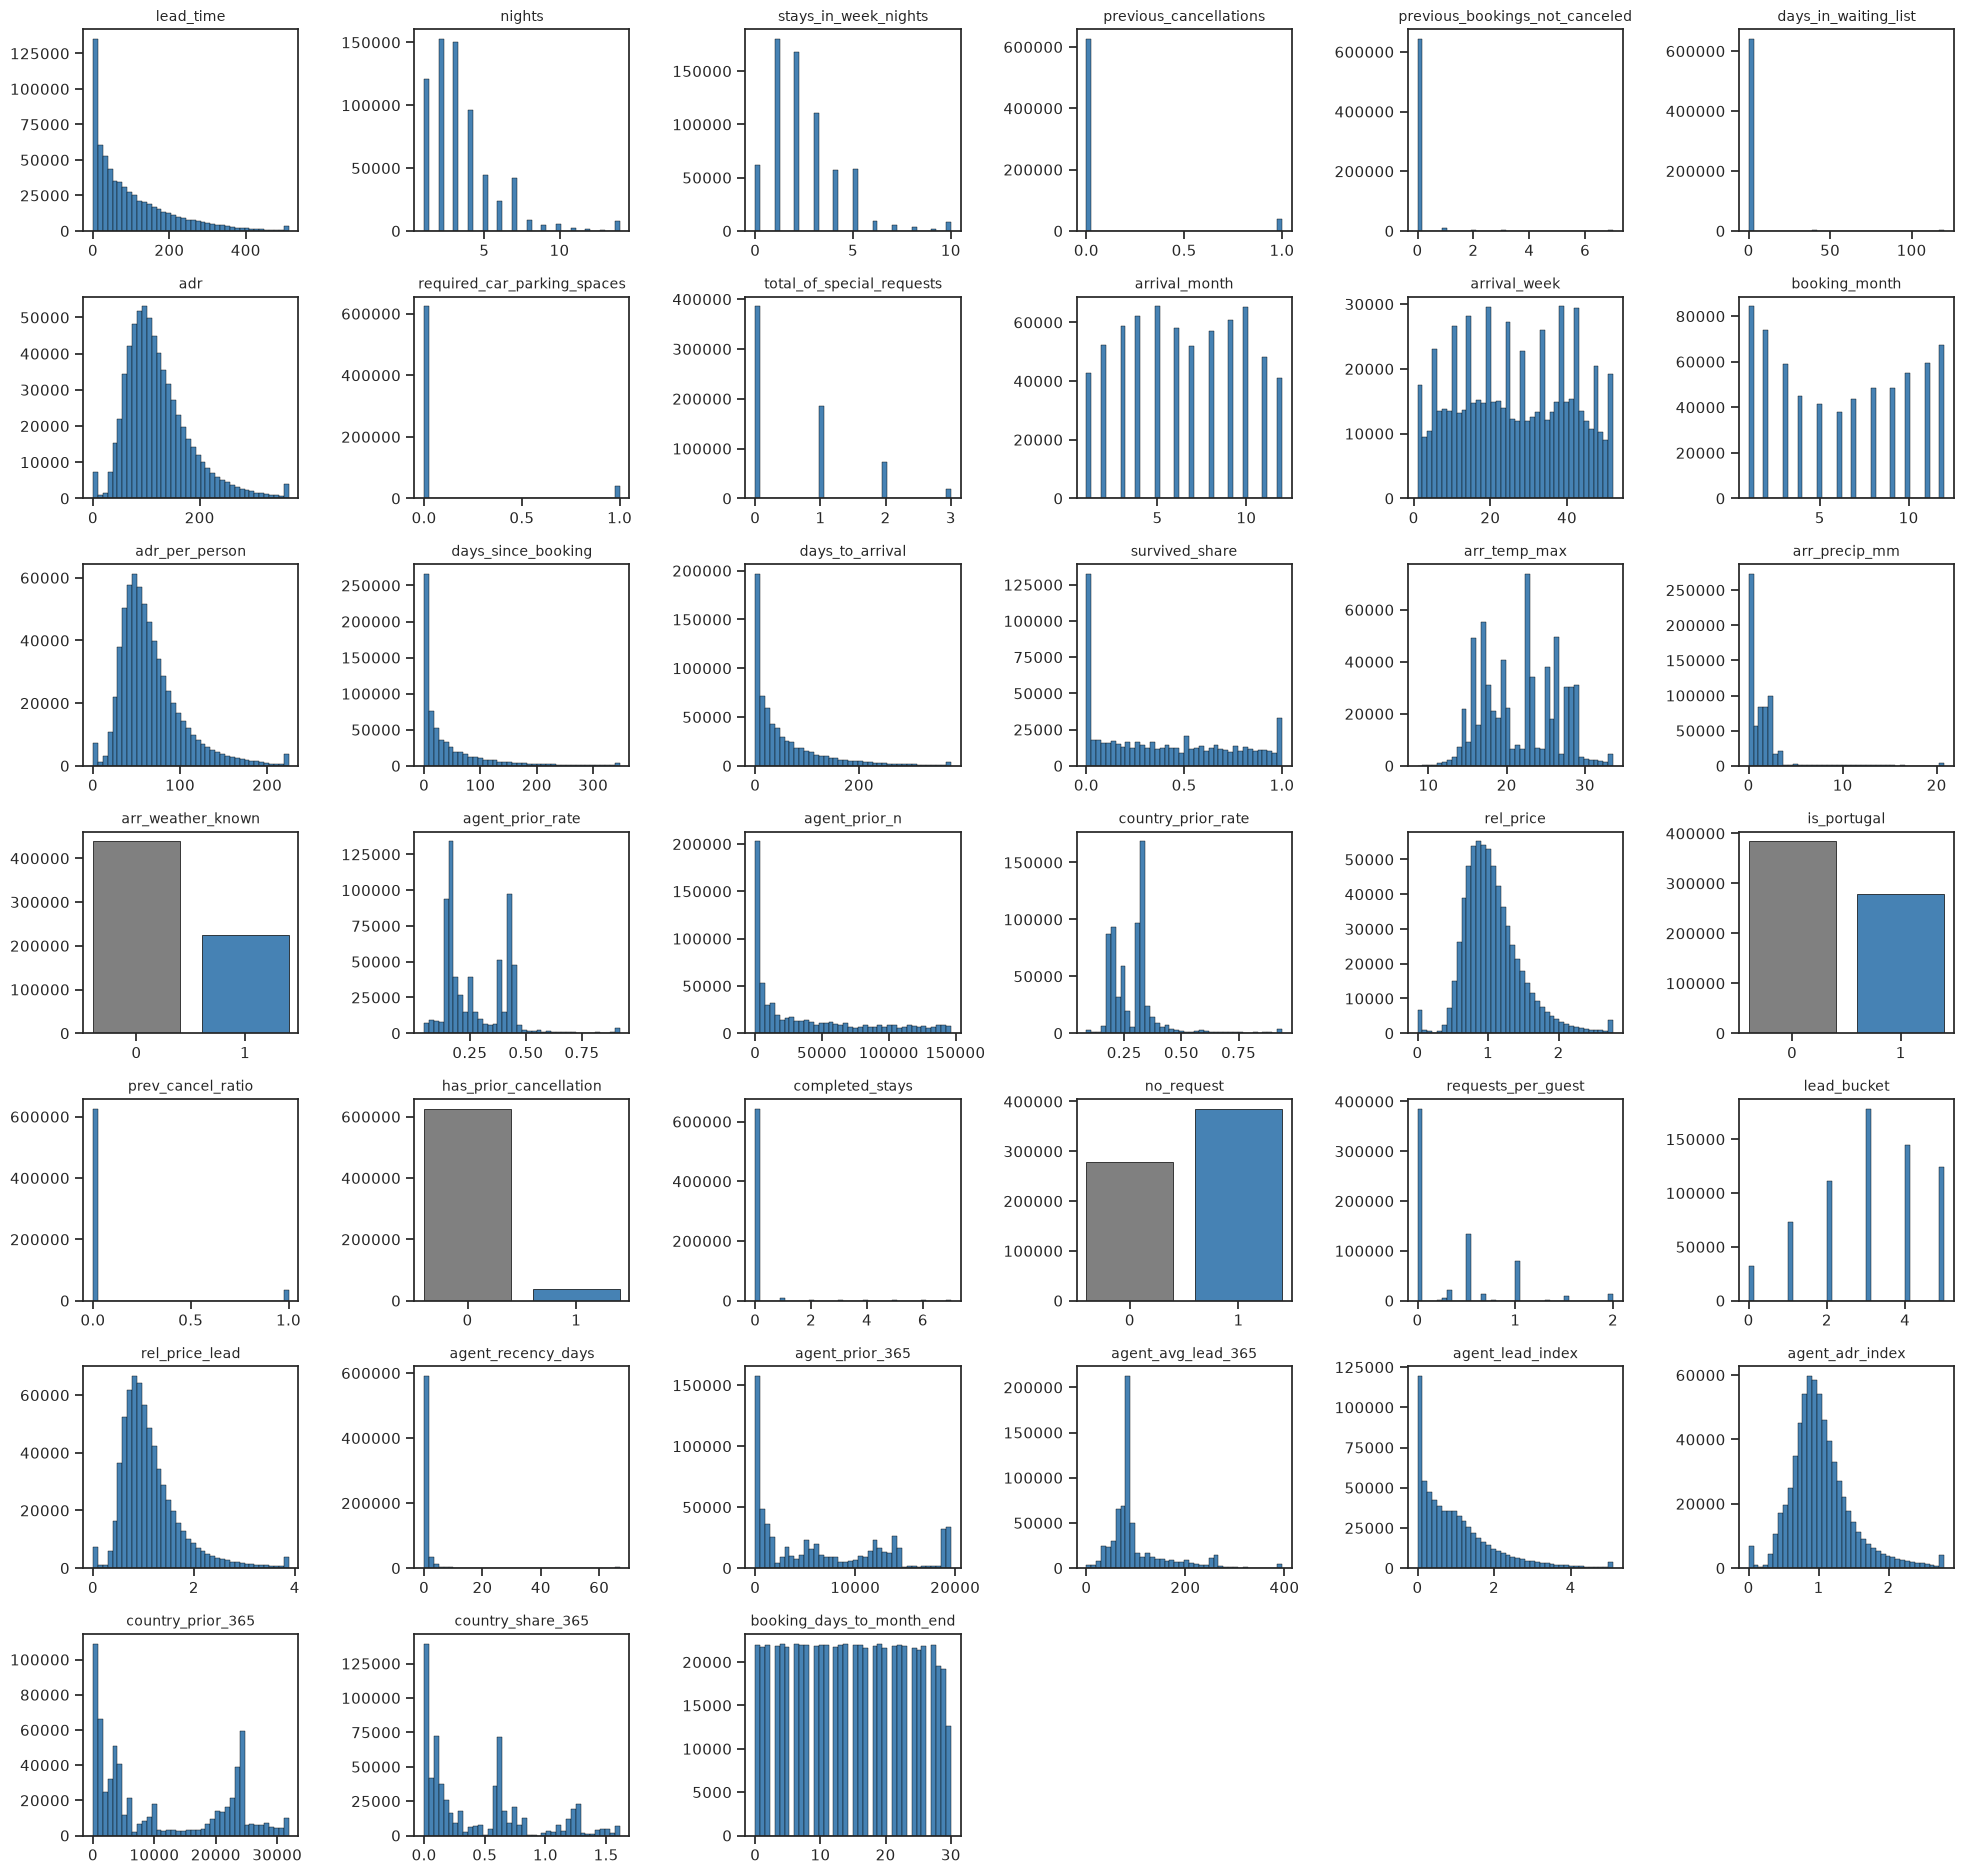

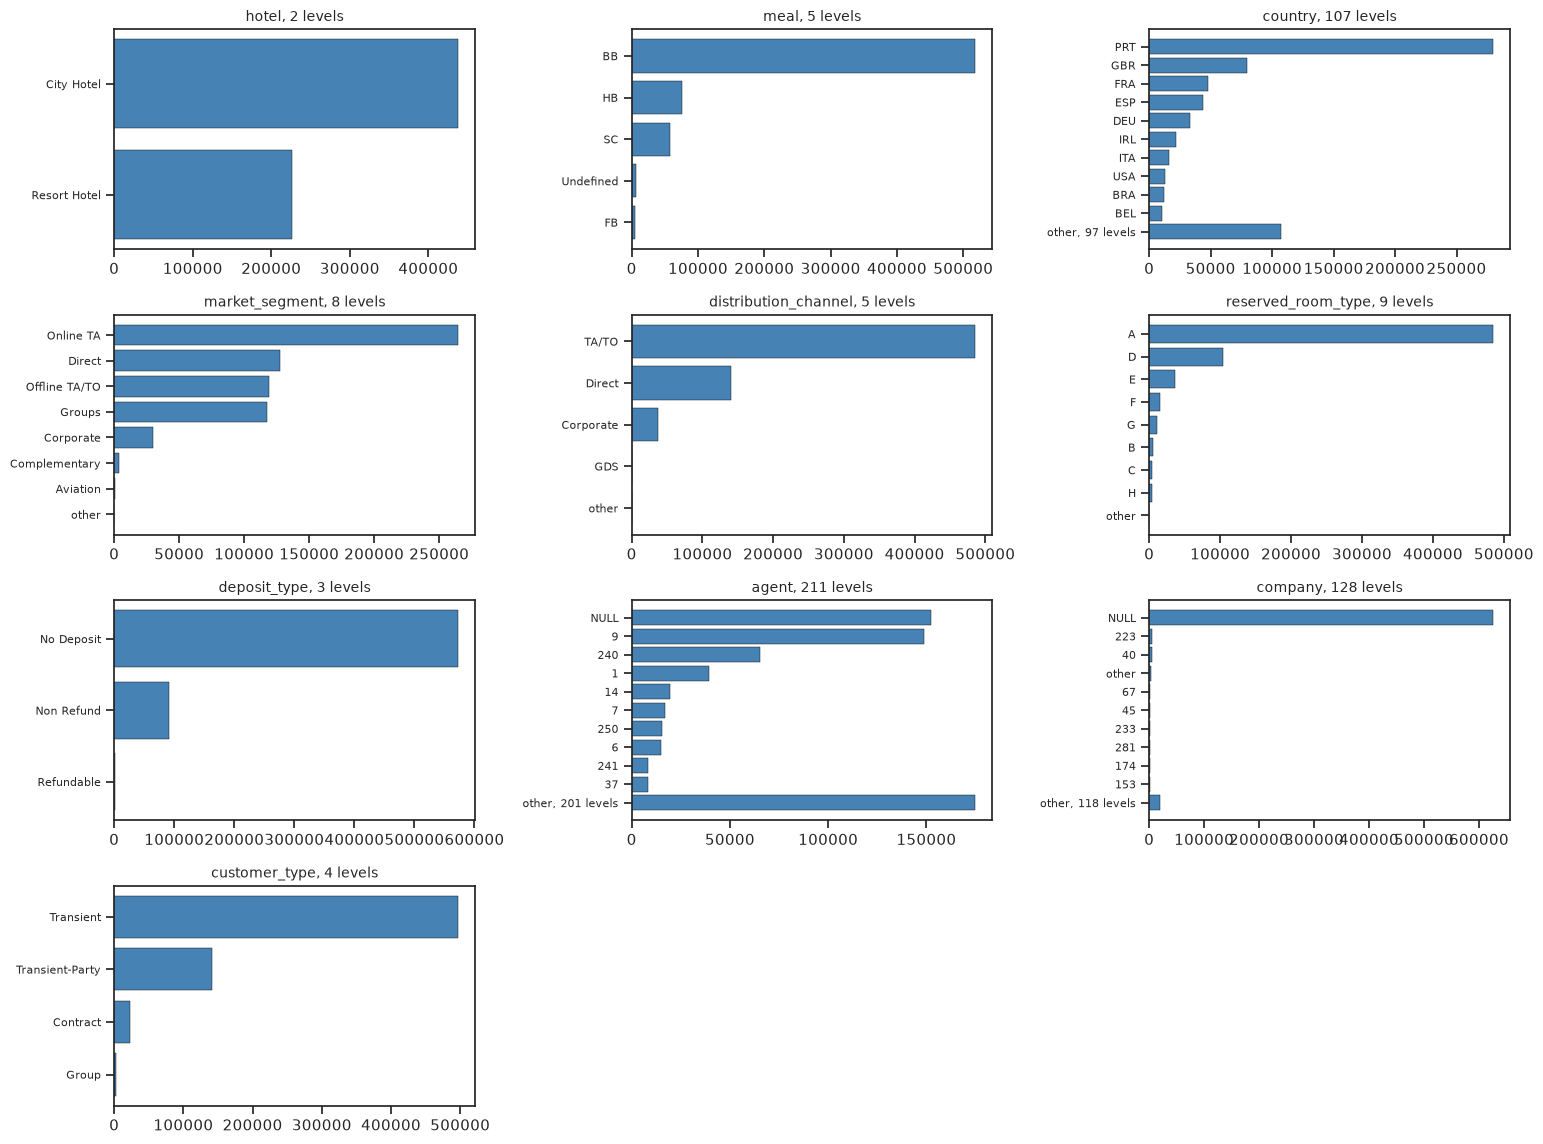

In [46]:
print("numeric features clipped at the " + str(clip_quantile) + " quantile for the histograms")
plot_histograms(x_cancel, cancel_numeric, ncols=6)
plot_category_bars(x_cancel, cancel_categorical, top=10, ncols=3)

                       feature    auc         direction   corr
                survived_share 0.7482 higher means less -0.370
               days_to_arrival 0.6776 higher means more  0.213
              agent_prior_rate 0.6742 higher means more  0.258
            days_since_booking 0.6533 higher means less -0.155
             arr_weather_known 0.6157 higher means less -0.216
            country_prior_rate 0.5890 higher means more  0.108
              agent_lead_index 0.5798 higher means more  0.089
                   lead_bucket 0.5664 higher means more  0.116
                 agent_prior_n 0.5664 higher means more  0.088
                     lead_time 0.5658 higher means more  0.055
                 arr_precip_mm 0.5627 higher means more -0.012
                           adr 0.5597 higher means more  0.087
                   is_portugal 0.5582 higher means more  0.104
            requests_per_guest 0.5556 higher means less -0.087
               agent_prior_365 0.5542 higher means more

             feature  mutual_info  levels  rate_min  rate_max
               agent       0.0449     181     0.007     0.686
      market_segment       0.0277       7     0.153     0.391
             country       0.0137      86     0.080     0.622
distribution_channel       0.0102       4     0.162     0.301
        deposit_type       0.0063       3     0.146     0.283
             company       0.0046      77     0.018     0.550
                meal       0.0030       5     0.153     0.371
       customer_type       0.0019       4     0.120     0.279
               hotel       0.0016       2     0.230     0.283
  reserved_room_type       0.0016       8     0.251     0.374


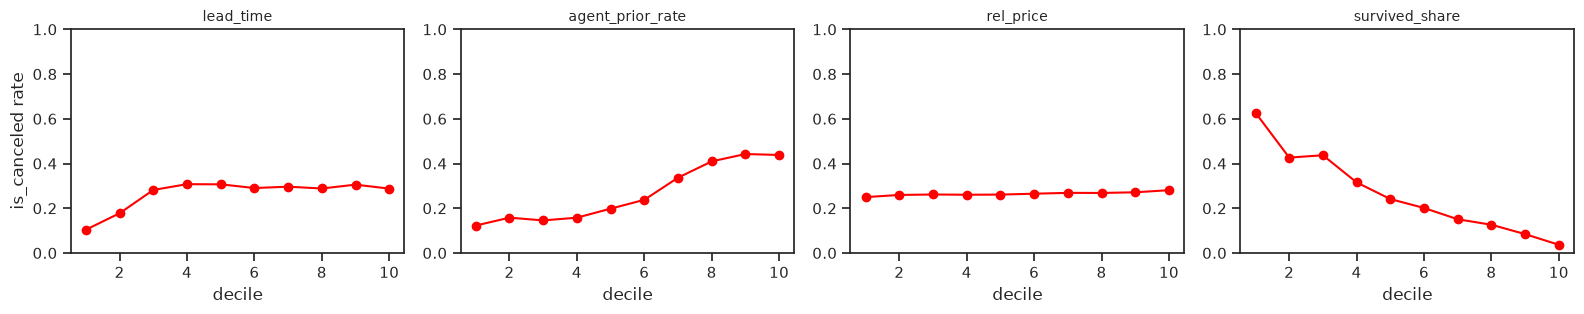

In [47]:
print(numeric_power(x_cancel, cancel_numeric, "is_canceled").to_string(index=False))
print(categorical_power(x_cancel, cancel_categorical, "is_canceled").to_string(index=False))
plot_rate_by_decile(x_cancel, [f for f in ["lead_time", "agent_prior_rate", "same_day_clones", "rel_price", "survived_share"] if f in cancel_numeric], "is_canceled")

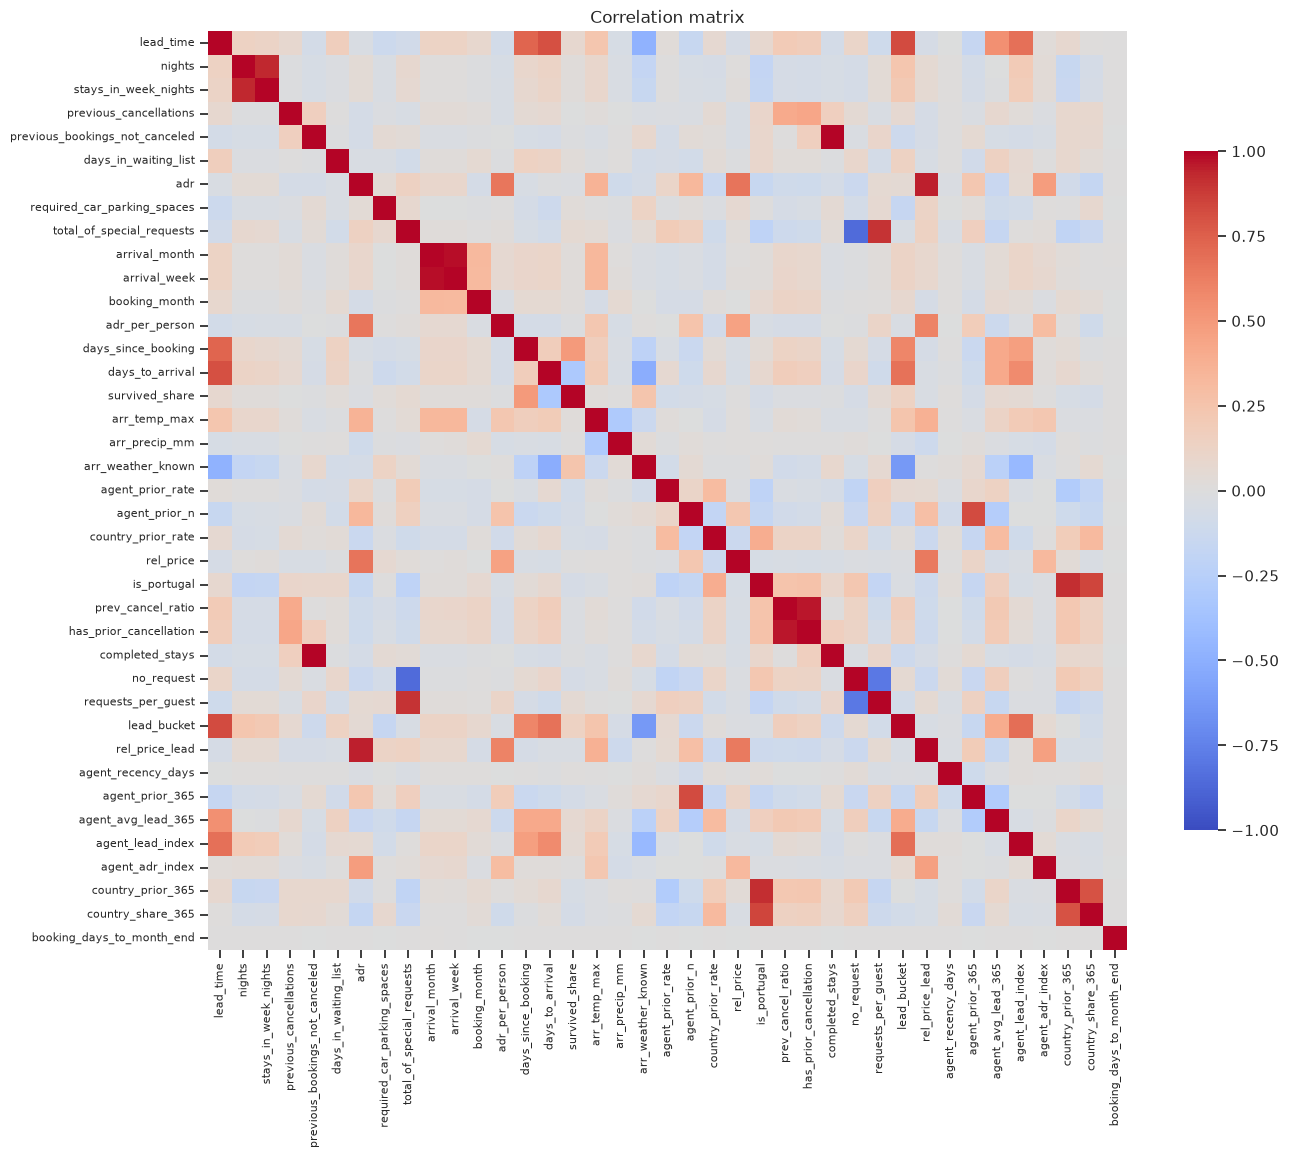

feature pairs with the largest absolute correlation
                     feature_a              feature_b  pearson
previous_bookings_not_canceled        completed_stays    1.000
                 arrival_month           arrival_week    0.977
             prev_cancel_ratio has_prior_cancellation    0.968
                           adr         rel_price_lead    0.946
                        nights   stays_in_week_nights    0.936
                   is_portugal      country_prior_365    0.916
     total_of_special_requests     requests_per_guest    0.905
     total_of_special_requests             no_request   -0.855
                   is_portugal      country_share_365    0.846
                 agent_prior_n        agent_prior_365    0.827
                     lead_time            lead_bucket    0.827
                     lead_time        days_to_arrival    0.805
variance inflation factor per numeric feature


rows used 663858 of 663858
                       feature  r2_on_others   vif                       identity_with    level
                     lead_time        1.0000   inf days_since_booking, days_to_arrival    exact
previous_bookings_not_canceled        1.0000   inf                     completed_stays    exact
            days_since_booking        1.0000   inf          lead_time, days_to_arrival    exact
               days_to_arrival        1.0000   inf       lead_time, days_since_booking    exact
               completed_stays        1.0000   inf      previous_bookings_not_canceled    exact
        has_prior_cancellation        0.9619 26.26                                         high
             prev_cancel_ratio        0.9610 25.64                                         high
                 arrival_month        0.9543 21.89                                         high
                  arrival_week        0.9542 21.81                                         high
             

features dropped as identities of others: lead_time, previous_bookings_not_canceled


rows used 663858 of 663858
                    feature  r2_on_others   vif identity_with    level
     has_prior_cancellation        0.9619 26.26                   high
          prev_cancel_ratio        0.9610 25.64                   high
              arrival_month        0.9543 21.89                   high
               arrival_week        0.9542 21.81                   high
                        adr        0.9486 19.45                   high
             rel_price_lead        0.9361 15.65                   high
                is_portugal        0.9197 12.45                   high
  total_of_special_requests        0.8934  9.38               moderate
          country_prior_365        0.8860  8.77               moderate
                     nights        0.8788  8.25               moderate
       stays_in_week_nights        0.8758  8.05               moderate
         requests_per_guest        0.8688  7.62               moderate
                lead_bucket        0.8364  6.11   

In [48]:
corr_cancel = plot_correlation(x_cancel, cancel_numeric)
print("feature pairs with the largest absolute correlation")
print(top_pairs(corr_cancel).to_string(index=False))
print("variance inflation factor per numeric feature")
print(vif_table(x_cancel, cancel_numeric).to_string(index=False))
print("variance inflation factor without the identity members")
print(vif_without_identities(x_cancel, cancel_numeric).to_string(index=False))

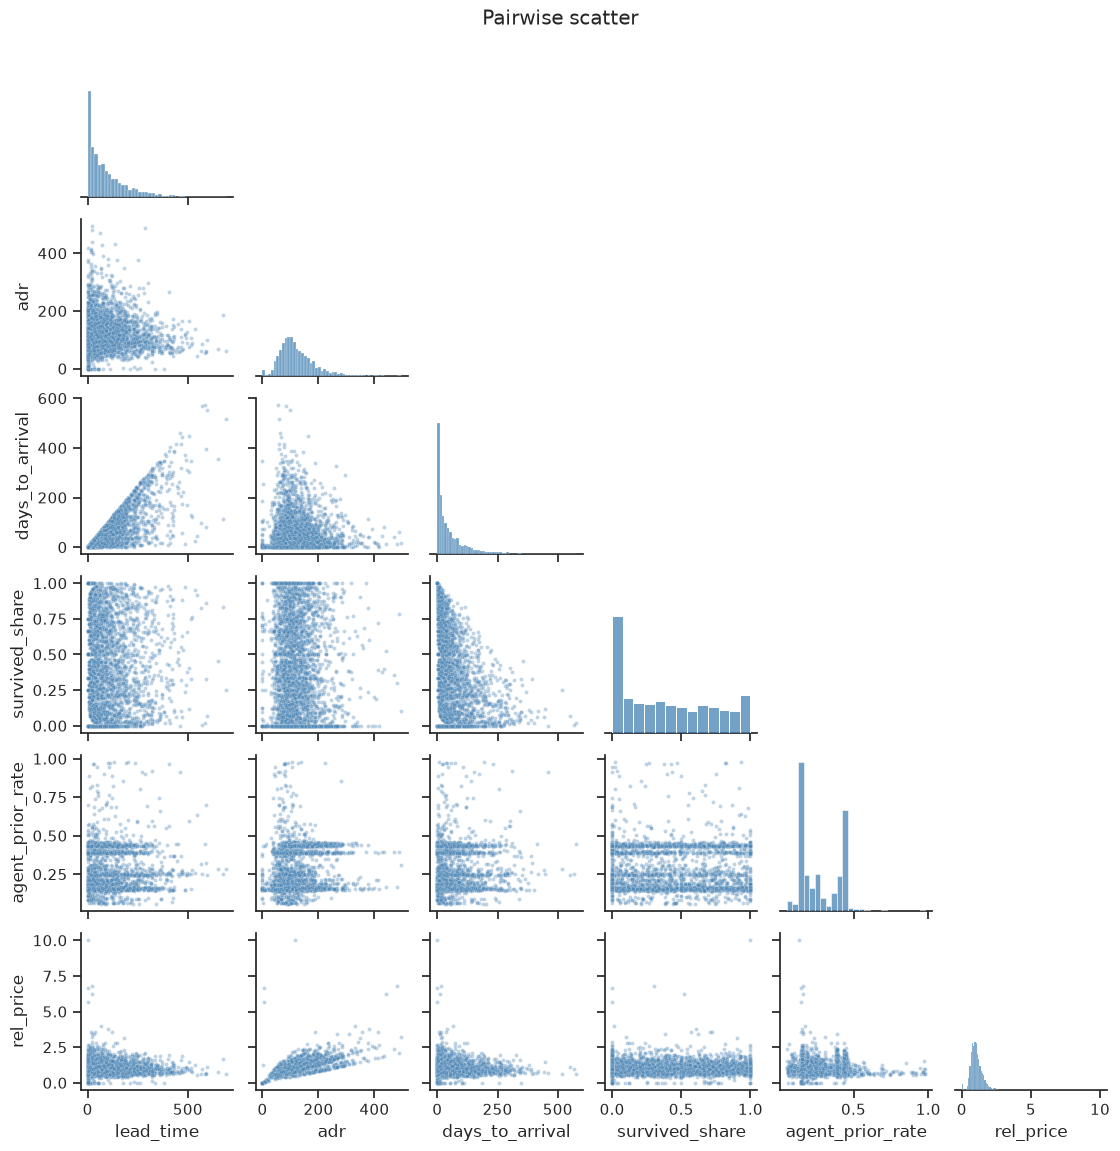

In [49]:
plot_pairs(x_cancel, [f for f in ["lead_time", "adr", "days_to_arrival", "survived_share", "agent_prior_rate", "rel_price"] if f in cancel_numeric])

### Channel effect model
* question: effect of booking direct instead of through an online travel agency on cancellation
* two targets: treated for the propensity model, is_canceled for the outcome models
* covariates: the numeric and categorical columns of the causal notebook, bookings of the two segments with no deposit

In [50]:
# bookings of the direct and online agency segments with no deposit, the treatment flag and the covariates of the causal model
def channel_sample(frame):
    out = frame[frame["market_segment"].isin(["Direct", "Online TA"]) & (frame["deposit_type"] == "No Deposit") & (frame["adr"] > 0) & (frame["adr"] < 1000) & (frame["outcome_known"] == True)].copy()
    out["is_canceled"] = out["is_canceled"].astype(int)
    out["treated"] = (out["market_segment"] == "Direct").astype(int)
    out["arrival_month"] = out["arrival_date"].dt.month
    out["arrival_dow"] = out["arrival_date"].dt.dayofweek
    out["booking_dow"] = out["booking_date"].dt.dayofweek
    top = out["country"].value_counts().head(8).index
    out["country_group"] = out["country"].where(out["country"].isin(top), "other")
    return out.reset_index(drop=True)

rows 386270, direct 122529, online ta 263741
cancel rate direct 0.1625, online ta 0.3912


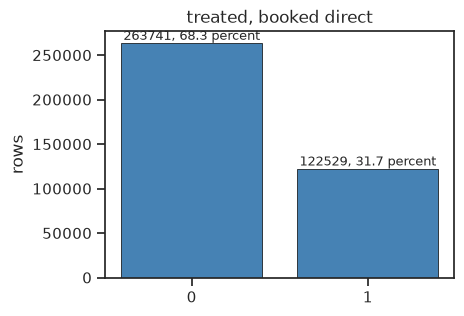

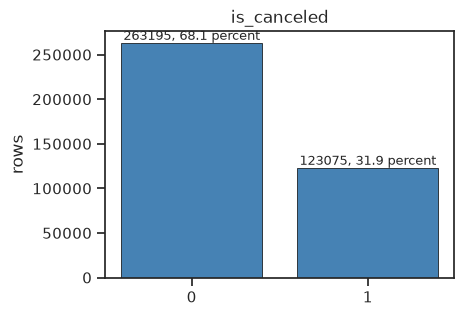

In [51]:
channel_numeric = ["lead_time", "nights", "adults", "children", "adr", "total_of_special_requests", "is_repeated_guest", "previous_cancellations", "arrival_month", "arrival_dow", "booking_dow", "same_day_clones", "country_prior_rate", "required_car_parking_spaces"]
channel_categorical = ["hotel", "country_group", "customer_type", "reserved_room_type", "meal"]
channel = channel_sample(bookings)
print("rows " + str(len(channel)) + ", direct " + str(int(channel["treated"].sum())) + ", online ta " + str(int((1 - channel["treated"]).sum())))
print("cancel rate direct " + str(round(float(channel.loc[channel["treated"] == 1, "is_canceled"].mean()), 4)) + ", online ta " + str(round(float(channel.loc[channel["treated"] == 0, "is_canceled"].mean()), 4)))
plot_target_bar(channel["treated"], "treated, booked direct")
plot_target_bar(channel["is_canceled"], "is_canceled")

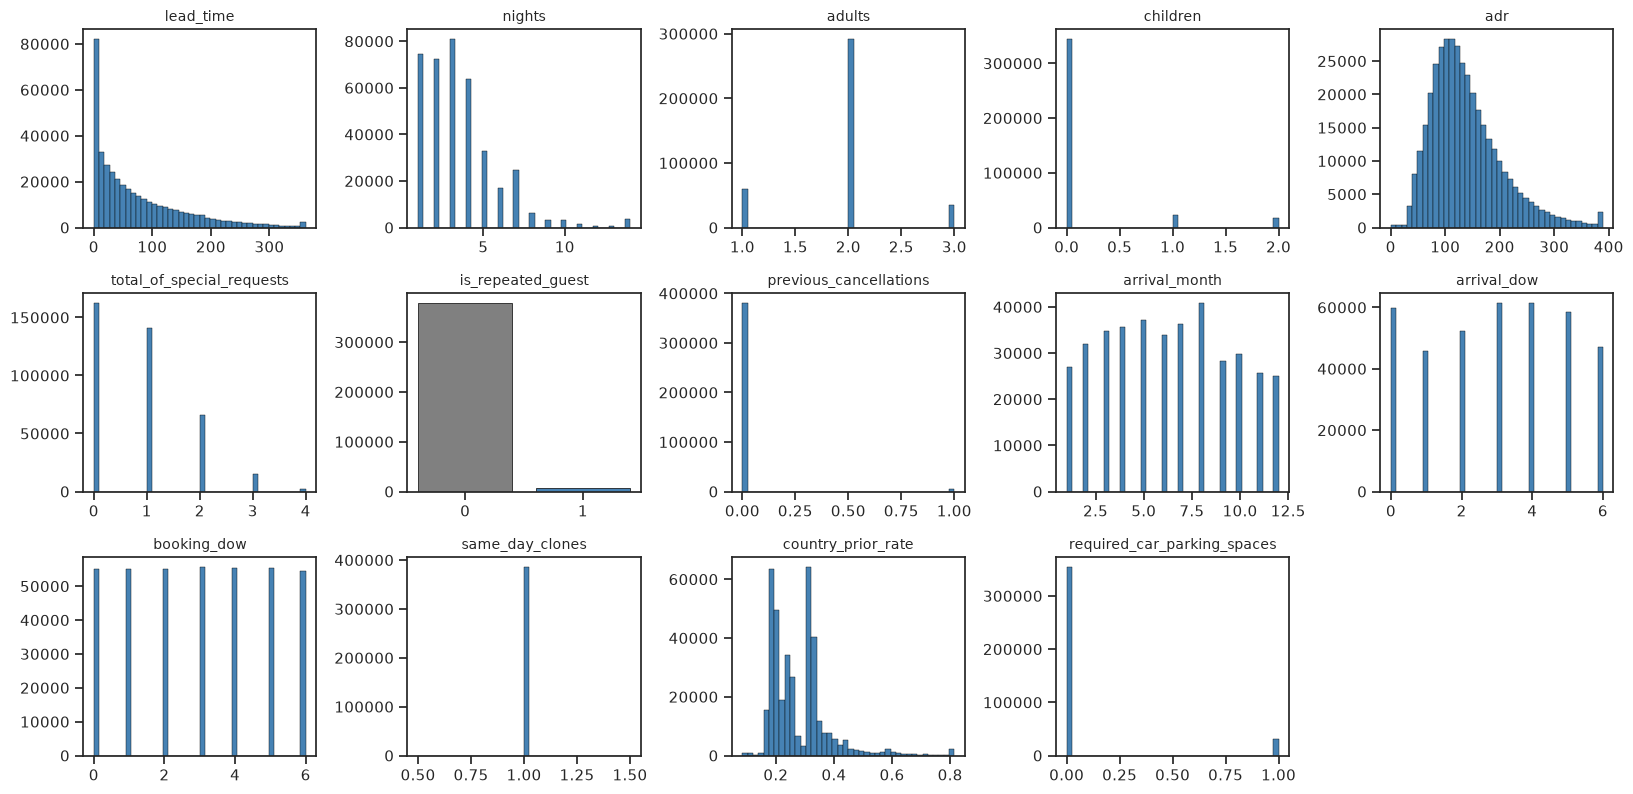

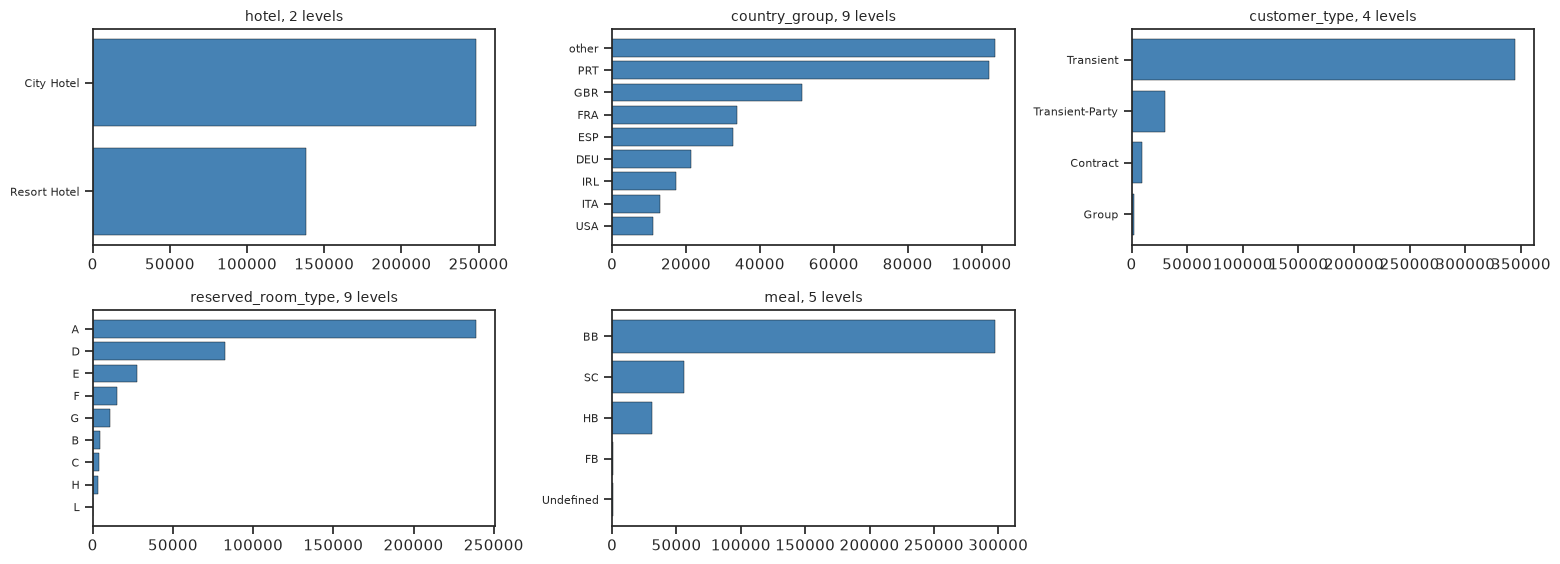

In [52]:
plot_histograms(channel, channel_numeric, ncols=5)
plot_category_bars(channel, channel_categorical, top=10, ncols=3)

                             pearson_with_treated
total_of_special_requests                  -0.122
is_repeated_guest                           0.096
lead_time                                  -0.085
required_car_parking_spaces                 0.081
adults                                     -0.066
adr                                         0.040
country_prior_rate                         -0.022
nights                                     -0.020
children                                   -0.005
arrival_month                              -0.005
same_day_clones                             0.005
previous_cancellations                      0.004
booking_dow                                -0.003
arrival_dow                                 0.001


                             pearson_with_is_canceled
required_car_parking_spaces                    -0.193
lead_time                                       0.177
total_of_special_requests                      -0.171
country_prior_rate                              0.122
nights                                          0.105
adr                                             0.067
is_repeated_guest                              -0.062
previous_cancellations                          0.053
adults                                          0.046
children                                        0.044
arrival_month                                   0.018
arrival_dow                                     0.004
same_day_clones                                -0.002
booking_dow                                     0.000


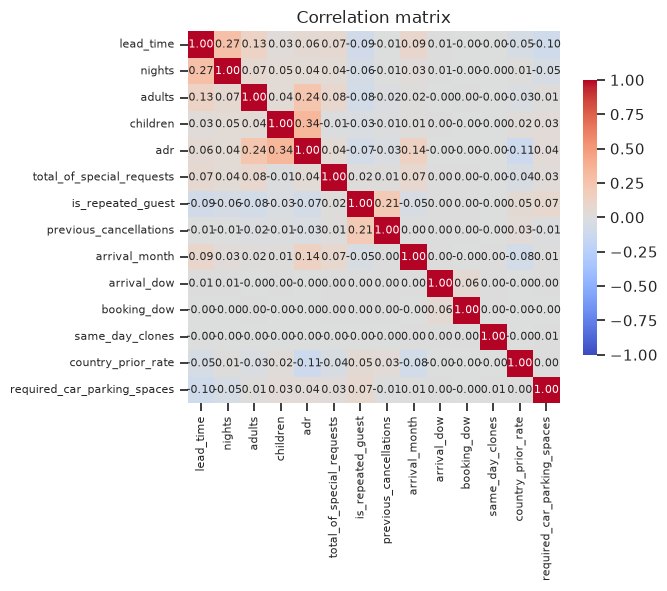

        feature_a                   feature_b  pearson
         children                         adr    0.341
        lead_time                      nights    0.275
           adults                         adr    0.239
is_repeated_guest      previous_cancellations    0.210
              adr               arrival_month    0.137
        lead_time                      adults    0.125
              adr          country_prior_rate   -0.114
        lead_time required_car_parking_spaces   -0.098


rows used 386270 of 386270
                    feature  r2_on_others  vif identity_with level
                        adr        0.1969 1.25                 low
                   children        0.1243 1.14                 low
                  lead_time        0.1081 1.12                 low
                     nights        0.0809 1.09                 low
                     adults        0.0818 1.09                 low
          is_repeated_guest        0.0681 1.07                 low
     previous_cancellations        0.0458 1.05                 low
              arrival_month        0.0366 1.04                 low
         country_prior_rate        0.0258 1.03                 low
  total_of_special_requests        0.0179 1.02                 low
required_car_parking_spaces        0.0192 1.02                 low
                arrival_dow        0.0036 1.00                 low
            same_day_clones        0.0001 1.00                 low
                booking_dow        

In [53]:
print(target_correlation(channel, channel_numeric, "treated").to_string())
print(target_correlation(channel, channel_numeric, "is_canceled").to_string())
corr_channel = plot_correlation(channel, channel_numeric)
print(top_pairs(corr_channel, 8).to_string(index=False))
print(vif_table(channel, channel_numeric).to_string(index=False))

### Demand forecast
* target: stayed arrivals per hotel and week
* features: the history of the series, the arrivals already on the books one to eight weeks before the week, last year's pickup ratio, Fourier terms of the yearly cycle
* the Eurostat nowcast: yearly log growth of Portugal hotel nights and the yearly change of the Wikipedia attention index

In [54]:
# weekly stayed arrivals per hotel, arrival weeks ending on sunday, the last incomplete week left out
def weekly_arrivals(frame):
    out = frame.copy()
    out["week"] = out["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    weekly = out[(out["is_canceled"] == 0) & (out["outcome_known"] == True)].groupby(["hotel", "week"]).size().rename("arrivals").reset_index()
    weekly = weekly[weekly["week"] < pd.Timestamp(datetime.date.today())]
    return weekly, out

In [55]:
# arrivals already on the books for each week as seen one to several weeks before the week, with the pickup ratio final over on the books
def weekly_on_books(frame, weekly, steps=8):
    out = weekly.set_index(["hotel", "week"]).copy()
    for h in range(1, steps + 1):
        cutoff = frame["week"] - pd.Timedelta(weeks=h)
        mask = (frame["booking_date"] <= cutoff) & (frame["leave_books_date"] > cutoff)
        otb = frame[mask].groupby(["hotel", "week"]).size()
        out["otb_" + str(h) + "w"] = otb.reindex(out.index).fillna(0).astype(int)
        out["ratio_" + str(h) + "w"] = out["arrivals"] / out["otb_" + str(h) + "w"].clip(lower=1)
    return out.reset_index()

In [56]:
# fourier terms of the yearly cycle plus a linear trend for a weekly index
def fourier_terms(index, k=3):
    woy = pd.Index(index).isocalendar().week.astype(float).values
    cols = {}
    for j in range(1, k + 1):
        cols["s" + str(j)] = np.sin(2 * np.pi * j * woy / 52)
        cols["c" + str(j)] = np.cos(2 * np.pi * j * woy / 52)
    cols["t"] = np.arange(len(index))
    return pd.DataFrame(cols, index=index)

City Hotel: 663 weeks from 2014-01-12 to 2026-09-20, mean arrivals 473.1, std 152.1
Resort Hotel: 663 weeks from 2014-01-12 to 2026-09-20, mean arrivals 262.7, std 80.9


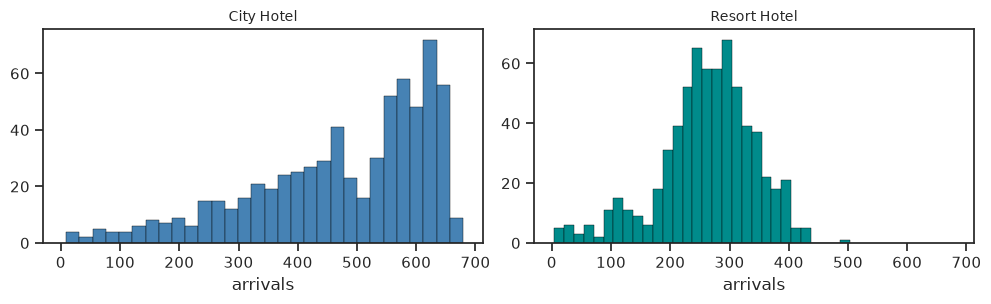

In [57]:
weekly, dated = weekly_arrivals(bookings)
for hotel in hotels:
    part = weekly[weekly["hotel"] == hotel]
    print(hotel + ": " + str(len(part)) + " weeks from " + str(part["week"].min().date()) + " to " + str(part["week"].max().date()) + ", mean arrivals " + str(round(float(part["arrivals"].mean()), 1)) + ", std " + str(round(float(part["arrivals"].std()), 1)))
plot_by_hotel(weekly, "arrivals")

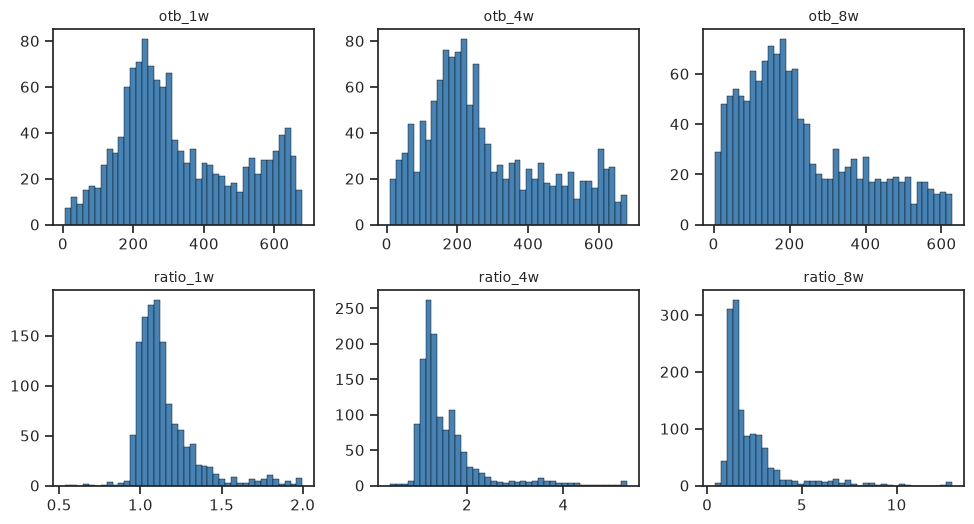

correlation of final arrivals with the arrivals on the books h weeks before, per hotel
        City Hotel  Resort Hotel
otb_1w       0.984         0.907
otb_2w       0.958         0.817
otb_3w       0.934         0.776
otb_4w       0.916         0.739
otb_5w       0.898         0.703
otb_6w       0.877         0.669
otb_7w       0.856         0.642
otb_8w       0.835         0.623
median pickup ratio by weeks before the arrival week, per hotel
              ratio_1w  ratio_2w  ratio_3w  ratio_4w  ratio_5w  ratio_6w  ratio_7w  ratio_8w
hotel                                                                                       
City Hotel       1.054     1.127     1.182     1.238     1.290     1.356     1.420      1.50
Resort Hotel     1.155     1.300     1.400     1.459     1.545     1.613     1.686      1.76


In [58]:
curve_weekly = weekly_on_books(dated, weekly)
plot_histograms(curve_weekly, ["otb_1w", "otb_4w", "otb_8w", "ratio_1w", "ratio_4w", "ratio_8w"], ncols=3)
corr_h = pd.DataFrame({hotel: [round(float(curve_weekly.loc[curve_weekly["hotel"] == hotel, "arrivals"].corr(curve_weekly.loc[curve_weekly["hotel"] == hotel, "otb_" + str(h) + "w"])), 3) for h in range(1, 9)] for hotel in hotels}, index=["otb_" + str(h) + "w" for h in range(1, 9)])
print("correlation of final arrivals with the arrivals on the books h weeks before, per hotel")
print(corr_h.to_string())
ratio_med = curve_weekly.groupby("hotel")[["ratio_" + str(h) + "w" for h in range(1, 9)]].median().round(3)
print("median pickup ratio by weeks before the arrival week, per hotel")
print(ratio_med.to_string())

In [59]:
fourier = fourier_terms(weekly[weekly["hotel"] == "City Hotel"]["week"])
print("variance inflation factor of the fourier terms and the trend")
print(vif_table(fourier, list(fourier.columns)).to_string(index=False))

variance inflation factor of the fourier terms and the trend
rows used 663 of 663
feature  r2_on_others  vif identity_with level
     s1        0.0030  1.0                 low
     c1        0.0030  1.0                 low
     s2        0.0023  1.0                 low
     c2        0.0022  1.0                 low
     s3        0.0023  1.0                 low
     c3        0.0021  1.0                 low
      t        0.0034  1.0                 low


#### Eurostat nowcast
* target: yearly log growth of monthly hotel nights in Portugal
* tested signal: yearly change of the log Wikipedia attention index across the main source market languages

In [60]:
# monthly portugal nights with the yearly log growth and the yearly change of the pageview index
def nowcast_frame(eurostat_path, pageviews_path):
    nights = pd.read_parquet(eurostat_path)
    nights = nights[nights["geo"] == "PT"].copy()
    nights["month"] = pd.to_datetime(nights["month"])
    frame = nights.set_index("month")[["nights"]].sort_index()
    pv = pd.read_parquet(pageviews_path)
    pv["date"] = pd.to_datetime(pv["date"])
    pv = pv[pv["project"].isin(["en.wikipedia", "de.wikipedia", "fr.wikipedia", "es.wikipedia", "it.wikipedia", "pt.wikipedia"])]
    monthly = pv.groupby([pv["project"], pv["date"].dt.to_period("M")])["views"].sum().unstack(0)
    index = np.log(monthly.fillna(monthly.mean())).mean(axis=1)
    index.index = index.index.to_timestamp()
    frame = frame.join(index.rename("pageview_index"), how="outer")
    frame["log_nights"] = np.log(frame["nights"])
    frame["growth"] = frame["log_nights"] - frame["log_nights"].shift(12)
    frame["index_change"] = frame["pageview_index"] - frame["pageview_index"].shift(12)
    return frame

published months 150 from 2014-01-01 to 2026-06-01
              count        mean         std        min         1%         25%         50%         75%         99%         max
nights        150.0  4453490.67  2021856.67  100210.00  263596.85  2883418.50  4445092.50  6114400.50  8237532.10  8602636.00
growth        138.0        0.04        0.76      -3.94      -2.97        0.01        0.05        0.11        1.99        2.11
index_change  123.0       -0.08        0.22      -0.59      -0.58       -0.21       -0.10        0.07        0.35        0.39


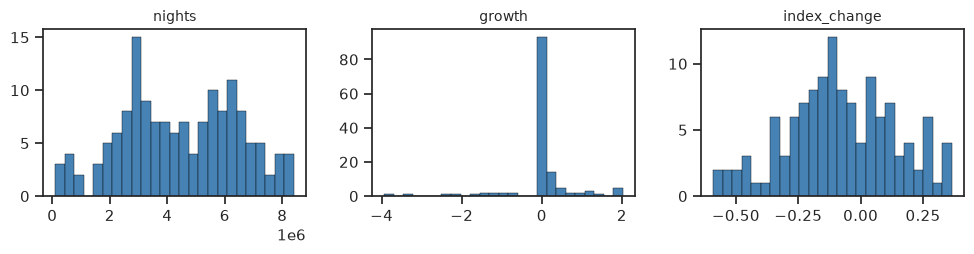

                pearson_with_growth
index_change                 -0.181
pageview_index                0.054


In [61]:
nowcast = nowcast_frame(EUROSTAT_PATH, PAGEVIEWS_PATH)
known = nowcast.dropna(subset=["nights"])
print("published months " + str(len(known)) + " from " + str(known.index.min().date()) + " to " + str(known.index.max().date()))
print(describe_numeric(nowcast[["nights", "growth", "index_change"]]).to_string())
plot_histograms(nowcast, ["nights", "growth", "index_change"], ncols=3, bins=25)
print(target_correlation(nowcast[nowcast.index >= "2024-01-01"], ["index_change", "pageview_index"], "growth").to_string())

### Booking curve forecast
* live model recomputed in the app on every request: rooms on the books per stay date times last year's pickup ratio at the same number of weeks out
* target: final rooms per hotel and stay date
* features: rooms on the books at zero to thirteen weeks before the stay date and the pickup ratio final over on the books at that distance

In [62]:
# rooms on the books per hotel and stay date at each number of weeks before the stay, with the final rooms and the pickup ratio
def booking_curve_table(nights, weeks=14):
    past = nights[nights["stay_date"] < pd.Timestamp(datetime.date.today())]
    out = past[past["is_canceled"] == 0].groupby(["hotel", "stay_date"]).size().rename("final").to_frame()
    for w in range(weeks):
        cutoff = nights["stay_date"] - pd.Timedelta(weeks=w)
        mask = (nights["booking_date"] <= cutoff) & (nights["leave_books_date"] > cutoff)
        otb = nights[mask].groupby(["hotel", "stay_date"]).size()
        out["otb_" + str(w) + "w"] = otb.reindex(out.index).fillna(0).astype(int)
        out["ratio_" + str(w) + "w"] = out["final"] / out["otb_" + str(w) + "w"].clip(lower=1)
    return out.reset_index()

In [63]:
# median pickup ratio with the 10th and 90th percentile band by weeks before the stay date, per hotel
def plot_pickup_curve(curve, weeks=14):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    for ax, hotel in zip(axes, hotels):
        part = curve[curve["hotel"] == hotel]
        cols = ["ratio_" + str(w) + "w" for w in range(weeks)]
        med = part[cols].median().values
        lo = part[cols].quantile(0.1).values
        hi = part[cols].quantile(0.9).values
        ax.fill_between(range(weeks), lo, hi, color=hotel_colors[hotel], alpha=0.2, label="10th to 90th percentile")
        ax.plot(range(weeks), med, marker="o", color=hotel_colors[hotel], label="median")
        ax.set_title(hotel, fontsize=10)
        ax.set_xlabel("weeks before the stay date")
        ax.legend()
    axes[0].set_ylabel("final rooms over rooms on the books")
    fig.suptitle("Pickup ratio by weeks out")
    plt.tight_layout()
    plt.show()

stay dates 9261, per hotel {'City Hotel': 4627, 'Resort Hotel': 4634}


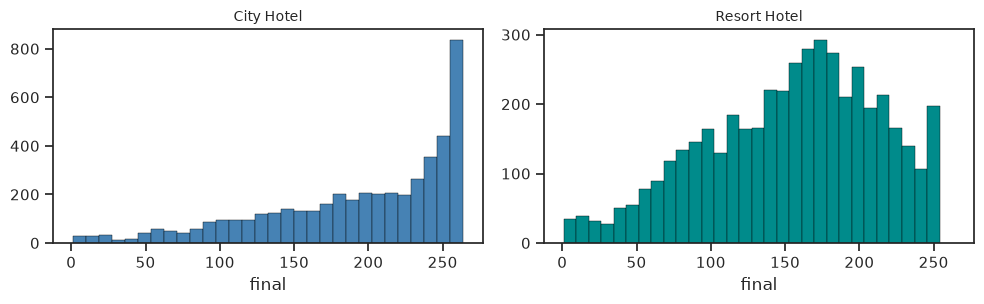

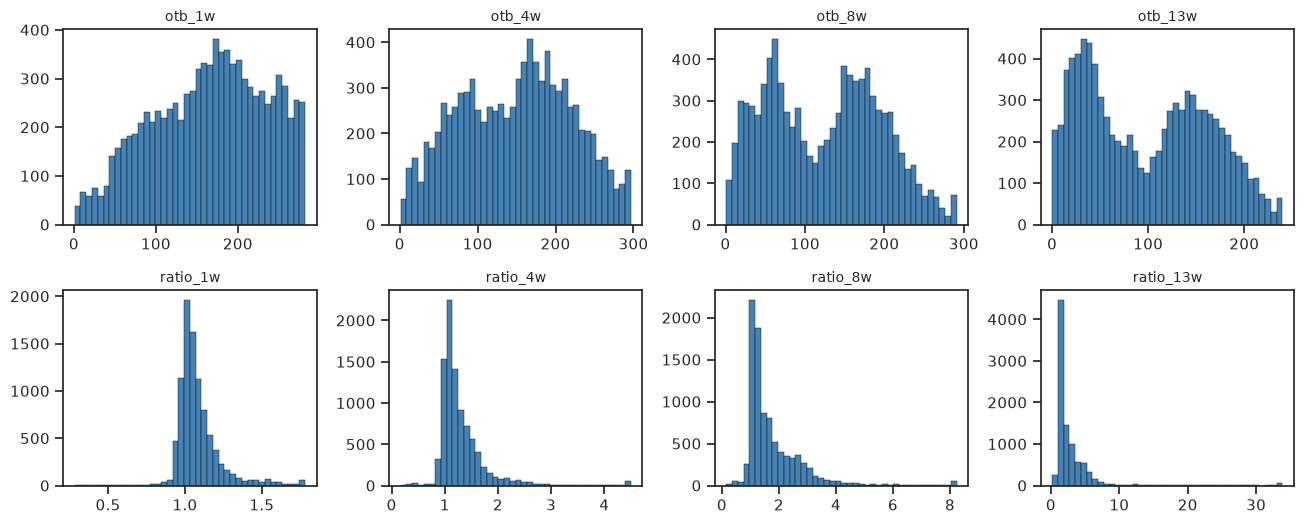

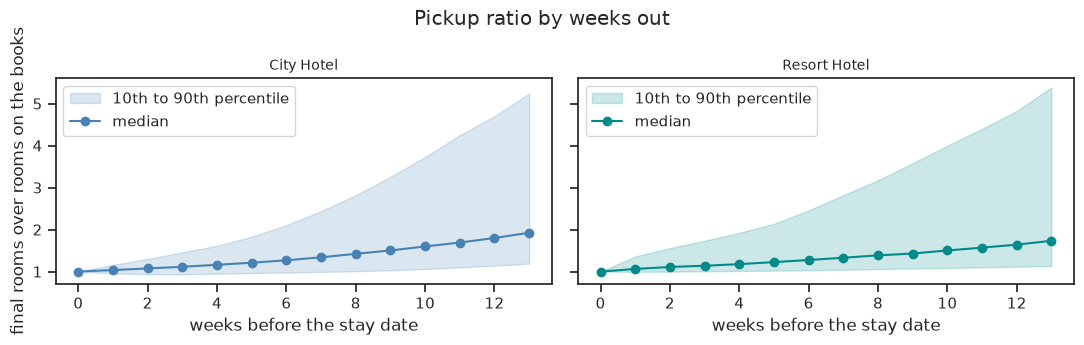

correlation of final rooms with the rooms on the books w weeks before the stay date, per hotel
         City Hotel  Resort Hotel
otb_0w        1.000         1.000
otb_1w        0.982         0.979
otb_2w        0.962         0.965
otb_3w        0.940         0.953
otb_4w        0.921         0.941
otb_5w        0.898         0.928
otb_6w        0.873         0.914
otb_7w        0.849         0.902
otb_8w        0.824         0.893
otb_9w        0.805         0.885
otb_10w       0.788         0.876
otb_11w       0.772         0.867
otb_12w       0.756         0.858
otb_13w       0.741         0.849


In [64]:
curve_daily = booking_curve_table(nights)
print("stay dates " + str(len(curve_daily)) + ", per hotel " + str(curve_daily.groupby("hotel").size().to_dict()))
plot_by_hotel(curve_daily, "final")
plot_histograms(curve_daily, ["otb_1w", "otb_4w", "otb_8w", "otb_13w", "ratio_1w", "ratio_4w", "ratio_8w", "ratio_13w"], ncols=4)
plot_pickup_curve(curve_daily)
corr_w = pd.DataFrame({hotel: [round(float(curve_daily.loc[curve_daily["hotel"] == hotel, "final"].corr(curve_daily.loc[curve_daily["hotel"] == hotel, "otb_" + str(w) + "w"])), 3) for w in range(14)] for hotel in hotels}, index=["otb_" + str(w) + "w" for w in range(14)])
print("correlation of final rooms with the rooms on the books w weeks before the stay date, per hotel")
print(corr_w.to_string())

### Price elasticity
* target: log daily pickup, bookings made per day for a hotel, segment and arrival week cell
* regressors: log rate offered that day, log days to arrival, booking weekday, log rooms on the books, log pace of the last seven days, holidays in the arrival week, Wikipedia attention in the booking week
* cancellation response: is_canceled against the log rate relative to the hotel, segment and month median

In [65]:
# bookings with cleaned rates, the arrival week and the season used by the elasticity panel
def elasticity_bookings(frame):
    out = frame[(frame["adr"] > 10) & (frame["adr"] < 1000) & (frame["nights"] > 0) & (frame["lead_time"] <= 365)].copy()
    out["month"] = out["arrival_date"].dt.month
    out["arrival_week"] = out["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    return out

In [66]:
# daily pickup panel: bookings made per day for each hotel, segment and arrival week, with the mean rate of those bookings
def pickup_panel(frame):
    grp = frame.groupby(["hotel", "market_segment", "arrival_week", "booking_date"])
    panel = grp.agg(pickup=("booking_id", "size"), room_nights=("nights", "sum"), rate=("adr", "mean"), lead=("lead_time", "mean")).reset_index()
    panel["days_to_arrival"] = (panel["arrival_week"] - panel["booking_date"]).dt.days
    panel["booking_dow"] = panel["booking_date"].dt.dayofweek
    panel["log_pickup"] = np.log(panel["pickup"])
    panel["log_rate"] = np.log(panel["rate"])
    return panel

In [67]:
# rooms already on the books for the arrival week at the start of each booking day and the pickup of the previous seven days
def add_on_books(panel, frame):
    out = []
    for (hotel, week), part in panel.groupby(["hotel", "arrival_week"]):
        rows = frame[(frame["hotel"] == hotel) & (frame["arrival_week"] == week)]
        booked = rows["booking_date"].values
        leaves = rows["leave_books_date"].values
        days = part["booking_date"].values
        otb = np.array([int(((booked < d) & (leaves > d)).sum()) for d in days])
        pace = np.array([int(((booked >= d - np.timedelta64(7, "D")) & (booked < d)).sum()) for d in days])
        out.append(part.assign(on_books=otb, pace_7d=pace))
    return pd.concat(out, ignore_index=True)

In [68]:
# holiday counts per arrival week and the log attention index per booking week
def add_demand_shifters(panel, holidays_path, pageviews_path):
    hol = pd.read_parquet(holidays_path)
    hol["date"] = pd.to_datetime(hol["date"])
    hol = hol[hol["kind"] == "public"]
    hol["week"] = hol["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    counts = hol.groupby("week").size()
    panel["holidays_arrival_week"] = panel["arrival_week"].map(counts).fillna(0)
    pv = pd.read_parquet(pageviews_path)
    pv["date"] = pd.to_datetime(pv["date"])
    pv = pv[pv["project"].isin(["en.wikipedia", "de.wikipedia", "fr.wikipedia", "es.wikipedia", "pt.wikipedia"])]
    weekly = np.log(pv.groupby(pv["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize())["views"].sum())
    panel["attention_booking_week"] = panel["booking_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize().map(weekly).fillna(weekly.mean())
    return panel

In [69]:
# the transformed regressors of the pickup specification
def panel_regressors(panel):
    out = pd.DataFrame(index=panel.index)
    out["log_rate"] = panel["log_rate"]
    out["log1p_days_to_arrival"] = np.log1p(panel["days_to_arrival"])
    out["log1p_on_books"] = np.log1p(panel["on_books"])
    out["log1p_pace_7d"] = np.log1p(panel["pace_7d"])
    out["holidays_arrival_week"] = panel["holidays_arrival_week"]
    out["attention_booking_week"] = panel["attention_booking_week"]
    out["booking_dow"] = panel["booking_dow"]
    out["log_pickup"] = panel["log_pickup"]
    return out

panel rows 403612, cells 5422, arrival weeks 699


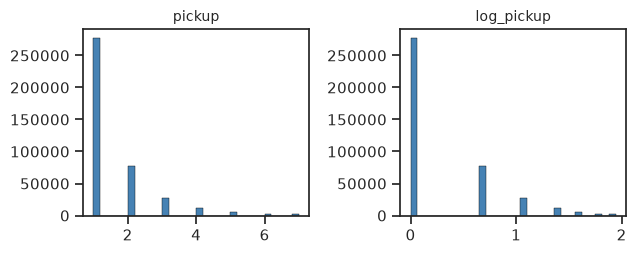

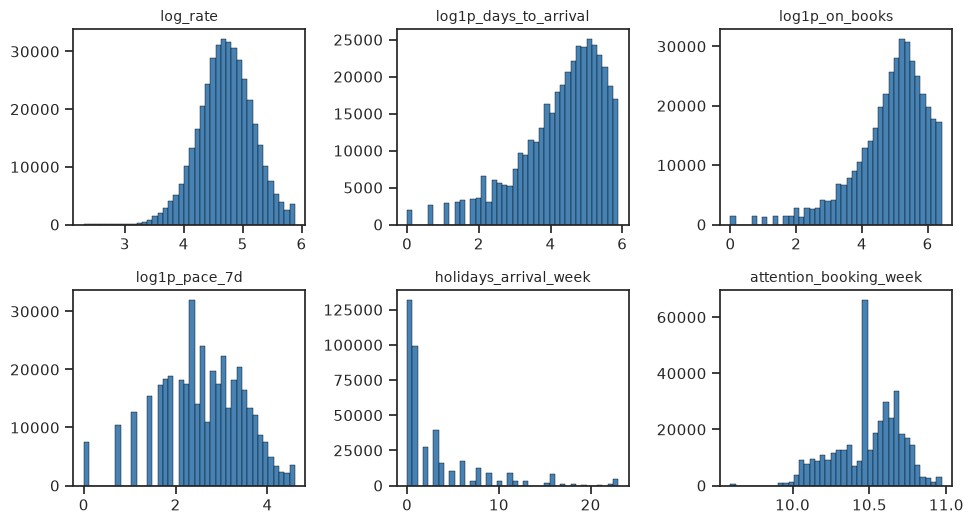

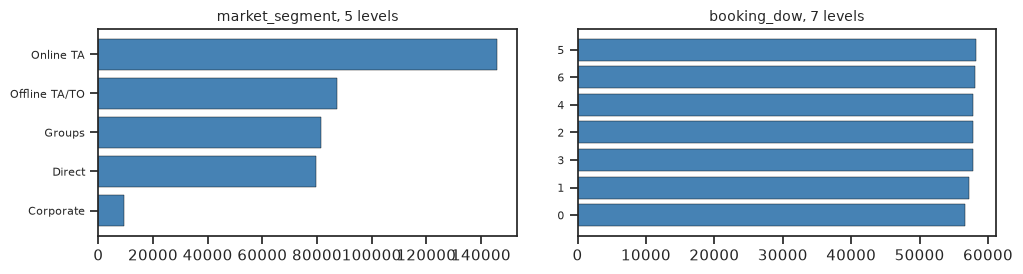

In [70]:
elastic = elasticity_bookings(bookings)
panel = add_demand_shifters(add_on_books(pickup_panel(elastic), elastic), HOLIDAYS_PATH, PAGEVIEWS_PATH)
cells_ok = panel.groupby(["hotel", "market_segment", "arrival_week"])["booking_date"].transform("size") >= 20
panel = panel[cells_ok].reset_index(drop=True)
regressors = panel_regressors(panel)
print("panel rows " + str(len(panel)) + ", cells " + str(panel.groupby(["hotel", "market_segment", "arrival_week"]).ngroups) + ", arrival weeks " + str(panel["arrival_week"].nunique()))
plot_histograms(panel, ["pickup", "log_pickup"], ncols=2, bins=30)
plot_histograms(regressors, ["log_rate", "log1p_days_to_arrival", "log1p_on_books", "log1p_pace_7d", "holidays_arrival_week", "attention_booking_week"], ncols=3)
plot_category_bars(panel, ["market_segment", "booking_dow"], top=10, ncols=2)

                        pearson_with_log_pickup
log1p_pace_7d                             0.400
log1p_days_to_arrival                    -0.359
log1p_on_books                            0.296
log_rate                                  0.082
attention_booking_week                   -0.003
holidays_arrival_week                     0.000


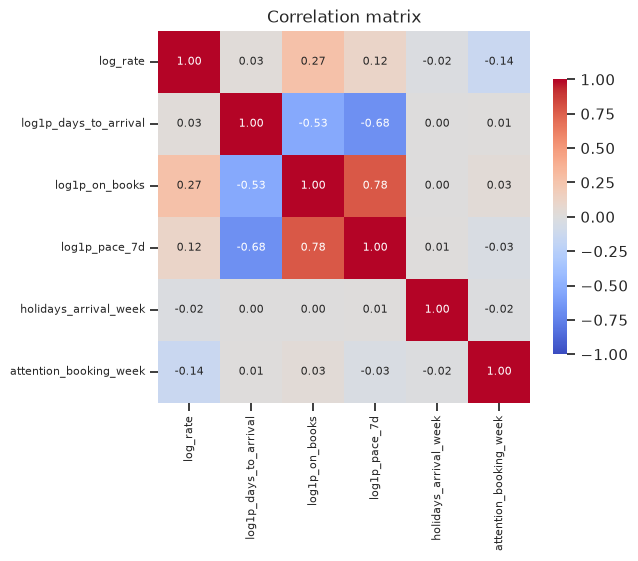

rows used 403612 of 403612
               feature  r2_on_others  vif identity_with level
         log1p_pace_7d        0.7080 3.42                 low
        log1p_on_books        0.6503 2.86                 low
 log1p_days_to_arrival        0.4714 1.89                 low
              log_rate        0.1461 1.17                 low
attention_booking_week        0.0410 1.04                 low
 holidays_arrival_week        0.0010 1.00                 low


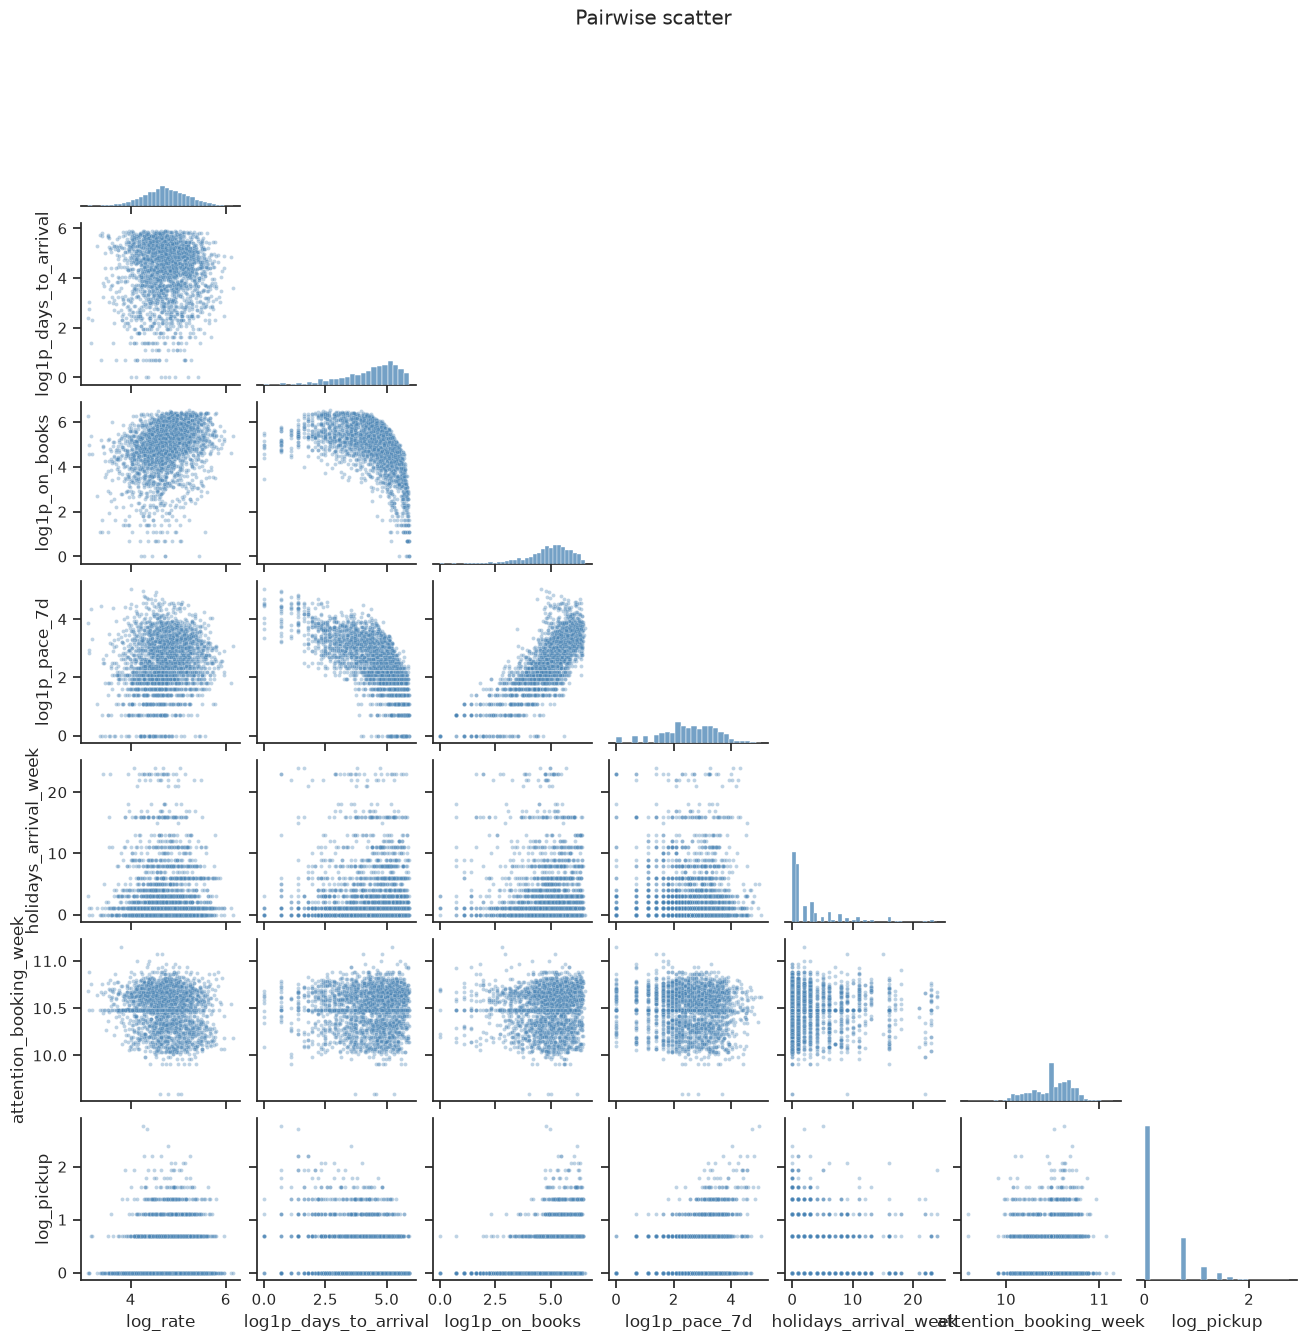

In [71]:
elastic_numeric = ["log_rate", "log1p_days_to_arrival", "log1p_on_books", "log1p_pace_7d", "holidays_arrival_week", "attention_booking_week"]
print(target_correlation(regressors, elastic_numeric, "log_pickup").to_string())
corr_elastic = plot_correlation(regressors, elastic_numeric)
print(vif_table(regressors, elastic_numeric).to_string(index=False))
plot_pairs(regressors, elastic_numeric + ["log_pickup"], n=2500)

#### Cancellation response to the relative rate
* target: is_canceled for bookings of the five main segments with no deposit
* regressor: log rate relative to the hotel, segment and arrival month median

In [72]:
# no deposit bookings of the main segments with the log rate relative to the hotel, segment and month median
def relative_rate_sample(frame):
    part = frame[frame["market_segment"].isin(["Online TA", "Offline TA/TO", "Direct", "Groups", "Corporate"]) & (frame["deposit_type"] == "No Deposit") & (frame["outcome_known"] == True)].copy()
    part["is_canceled"] = part["is_canceled"].astype(int)
    med = part.groupby(["hotel", "market_segment", "month"])["adr"].transform("median")
    part["rel_price"] = np.log(part["adr"] / med)
    return part

rows 555926


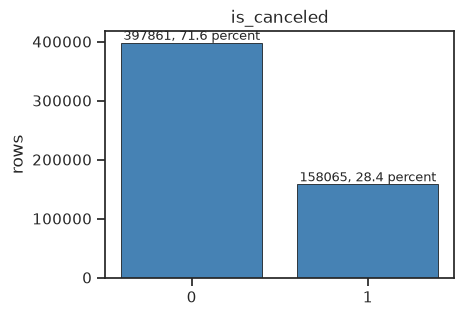

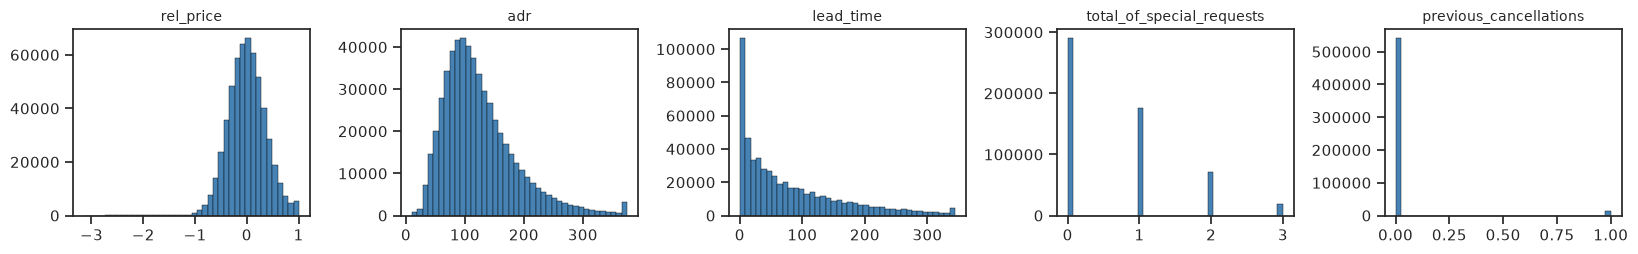

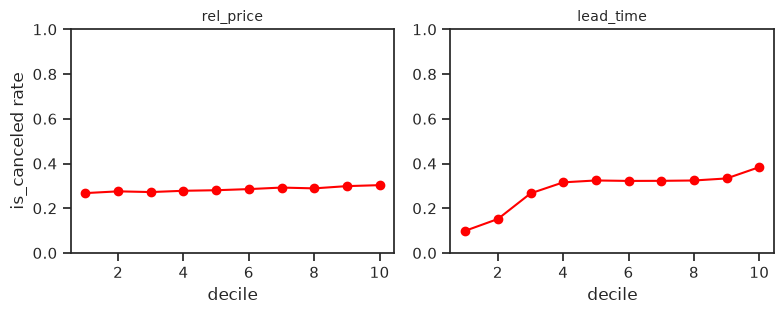

In [73]:
rel = relative_rate_sample(elastic)
print("rows " + str(len(rel)))
plot_target_bar(rel["is_canceled"], "is_canceled")
plot_histograms(rel, ["rel_price", "adr", "lead_time", "total_of_special_requests", "previous_cancellations"], ncols=5)
plot_rate_by_decile(rel, ["rel_price", "lead_time"], "is_canceled")

### Airbnb hedonic price model
* target: log nightly price of Lisbon Airbnb listings priced 20 to 1500 euros
* features: size, reviews, host, amenities, location and the neighbourhood, room type and property type
* multicollinearity of the full feature set and of the set without the redundant review scores and coordinates
* occupancy response: share of the next year booked against the gap between price and model value

In [74]:
# airbnb listings with price, occupancy proxy and cleaned features
def load_listings(listings_path, availability_path):
    frame = pd.read_parquet(listings_path)
    avail = pd.read_parquet(availability_path)
    frame["id"] = pd.to_numeric(frame["id"], errors="coerce")
    frame = frame.merge(avail, left_on="id", right_on="listing_id", how="left")
    frame["price"] = pd.to_numeric(frame["price_num"], errors="coerce")
    frame = frame[(frame["price"] >= 20) & (frame["price"] <= 1500)].copy()
    for col in ["accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "number_of_reviews", "review_scores_rating", "review_scores_location", "review_scores_value", "host_listings_count", "reviews_per_month", "latitude", "longitude", "availability_365"]:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")
    frame["superhost"] = (frame["host_is_superhost"] == "t").astype(int)
    frame["instant"] = (frame["instant_bookable"] == "t").astype(int)
    frame["booked_share"] = frame["booked_days"] / frame["days"]
    frame["log_price"] = np.log(frame["price"])
    frame["amenity_count"] = frame["amenities"].fillna("").str.count(",") + 1
    frame["dist_center_km"] = np.sqrt(((frame["latitude"] - 38.7139) * 111) ** 2 + ((frame["longitude"] + 9.1394) * 88) ** 2)
    return frame

listings 22478
                column   dtype  non_null  missing  missing_share  unique             example
          accommodates   int64     22478        0         0.0000      16                   3
              bedrooms float64     18581     3897         0.1734      17                 1.0
                  beds float64     21736      742         0.0330      28                 3.0
             bathrooms float64     20554     1924         0.0856      21                 1.0
        minimum_nights float64     22477        1         0.0000      44                 3.0
     number_of_reviews   int64     22478        0         0.0000     696                 119
  review_scores_rating float64     19861     2617         0.1164     157                 4.5
review_scores_location float64     19861     2617         0.1164     167                4.81
   review_scores_value float64     19861     2617         0.1164     168                4.37
   host_listings_count float64     22458       20      

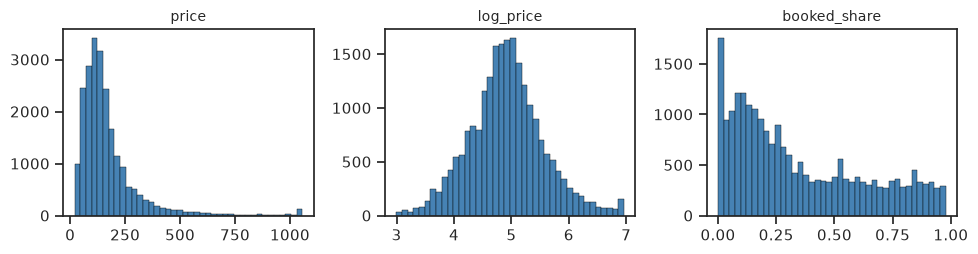

In [75]:
hedonic_numeric = ["accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "number_of_reviews", "review_scores_rating", "review_scores_location", "review_scores_value", "host_listings_count", "reviews_per_month", "superhost", "instant", "amenity_count", "dist_center_km", "latitude", "longitude"]
hedonic_categorical = ["neighbourhood_cleansed", "room_type", "property_type"]
listings = load_listings(LISTINGS_PATH, AVAILABILITY_PATH)
print("listings " + str(len(listings)))
print(overview_table(listings[hedonic_numeric + hedonic_categorical + ["price", "log_price", "booked_share"]]).to_string(index=False))
plot_histograms(listings, ["price", "log_price", "booked_share"], ncols=3, bins=40)

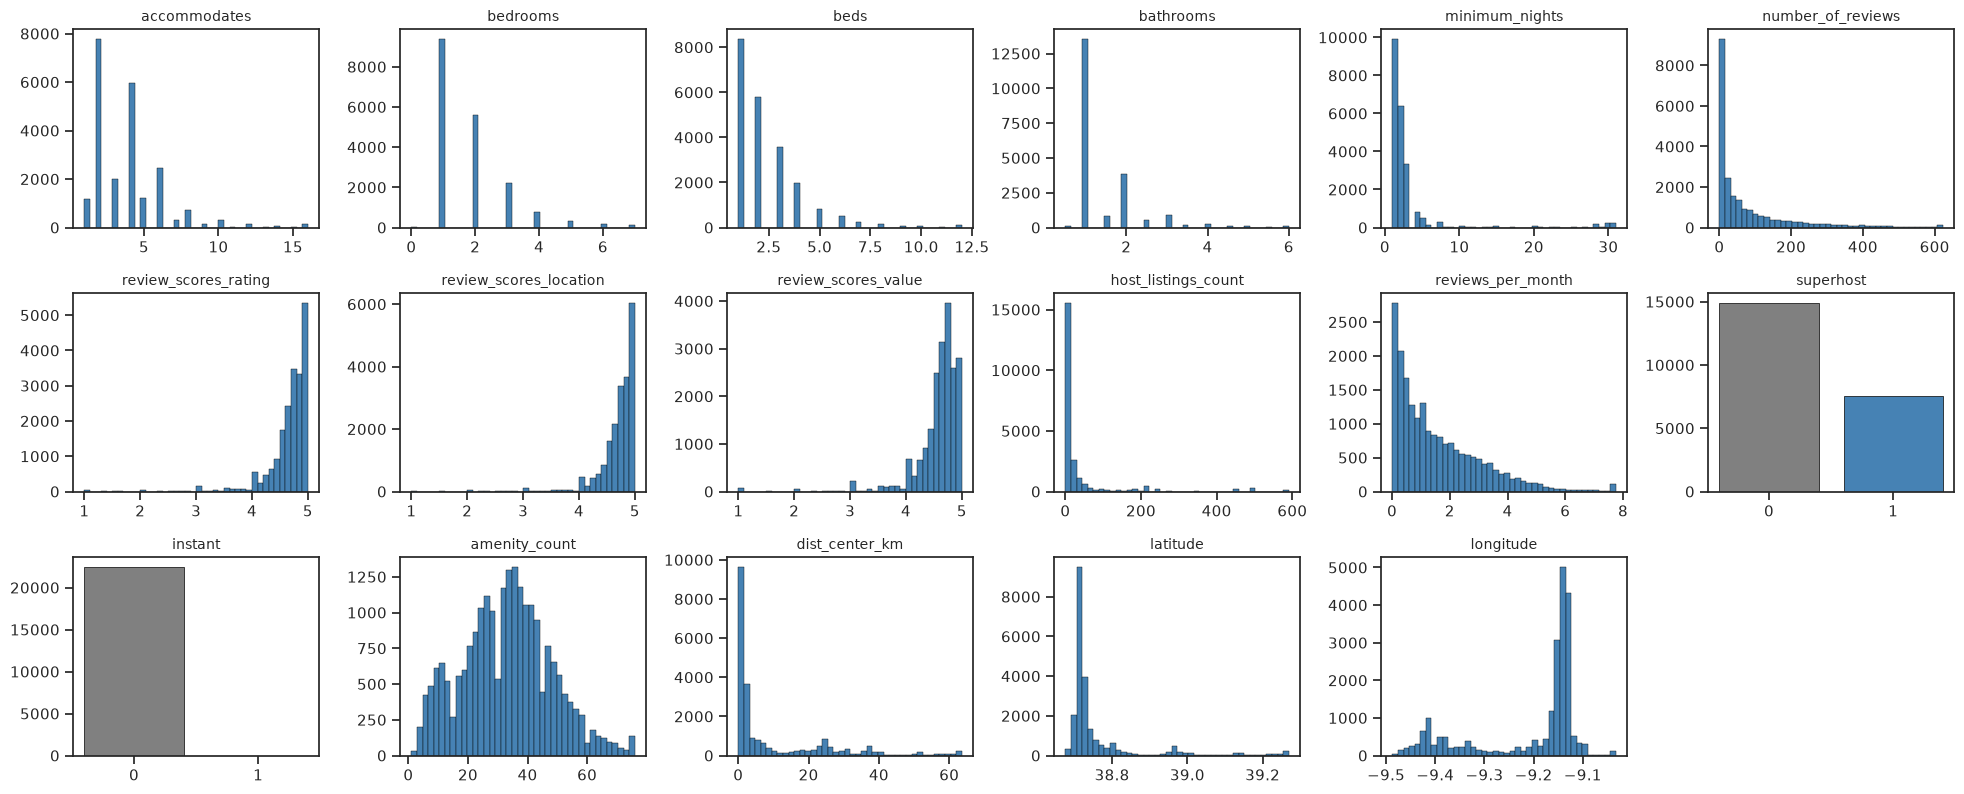

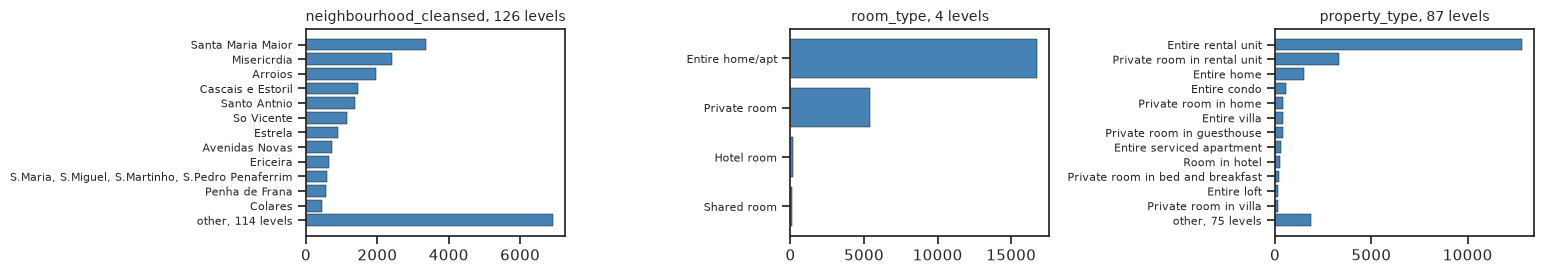

In [76]:
plot_histograms(listings, hedonic_numeric, ncols=6)
plot_category_bars(listings, hedonic_categorical, top=12, ncols=3)

                        pearson_with_log_price
accommodates                             0.660
bedrooms                                 0.535
beds                                     0.515
bathrooms                                0.322
amenity_count                            0.322
review_scores_rating                     0.188
review_scores_location                   0.175
longitude                               -0.166
review_scores_value                      0.139
superhost                                0.134
dist_center_km                           0.127
minimum_nights                          -0.123
reviews_per_month                       -0.050
latitude                                 0.047
number_of_reviews                        0.018
host_listings_count                     -0.003
                        pearson_with_booked_share
bathrooms                                   0.085
log_price                                  -0.060
bedrooms                                    0.060
r

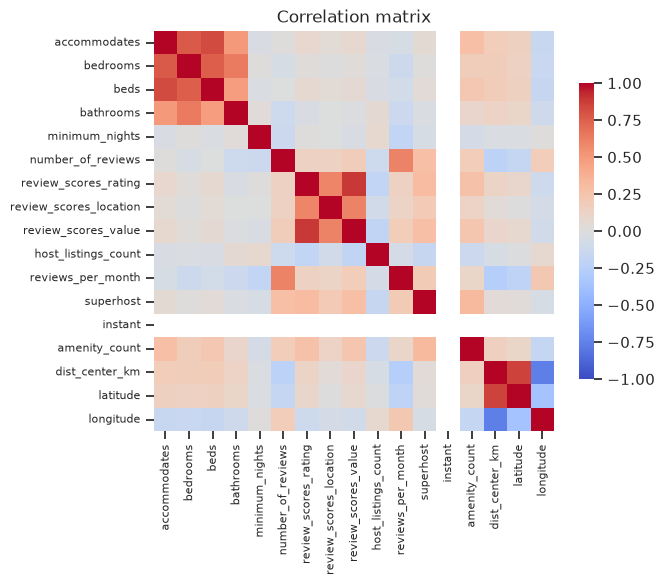

             feature_a              feature_b  pearson
  review_scores_rating    review_scores_value    0.885
        dist_center_km               latitude    0.855
          accommodates                   beds    0.826
          accommodates               bedrooms    0.772
        dist_center_km              longitude   -0.760
              bedrooms                   beds    0.757
              bedrooms              bathrooms    0.640
review_scores_location    review_scores_value    0.609
     number_of_reviews      reviews_per_month    0.605
  review_scores_rating review_scores_location    0.597
variance inflation factor, full feature set
rows used 14874 of 22478
constant features left out of the vif table: instant
               feature  r2_on_others   vif identity_with    level
        dist_center_km        0.9648 28.43                   high
              latitude        0.9242 13.19                   high
             longitude        0.8870  8.85               moderate
   review

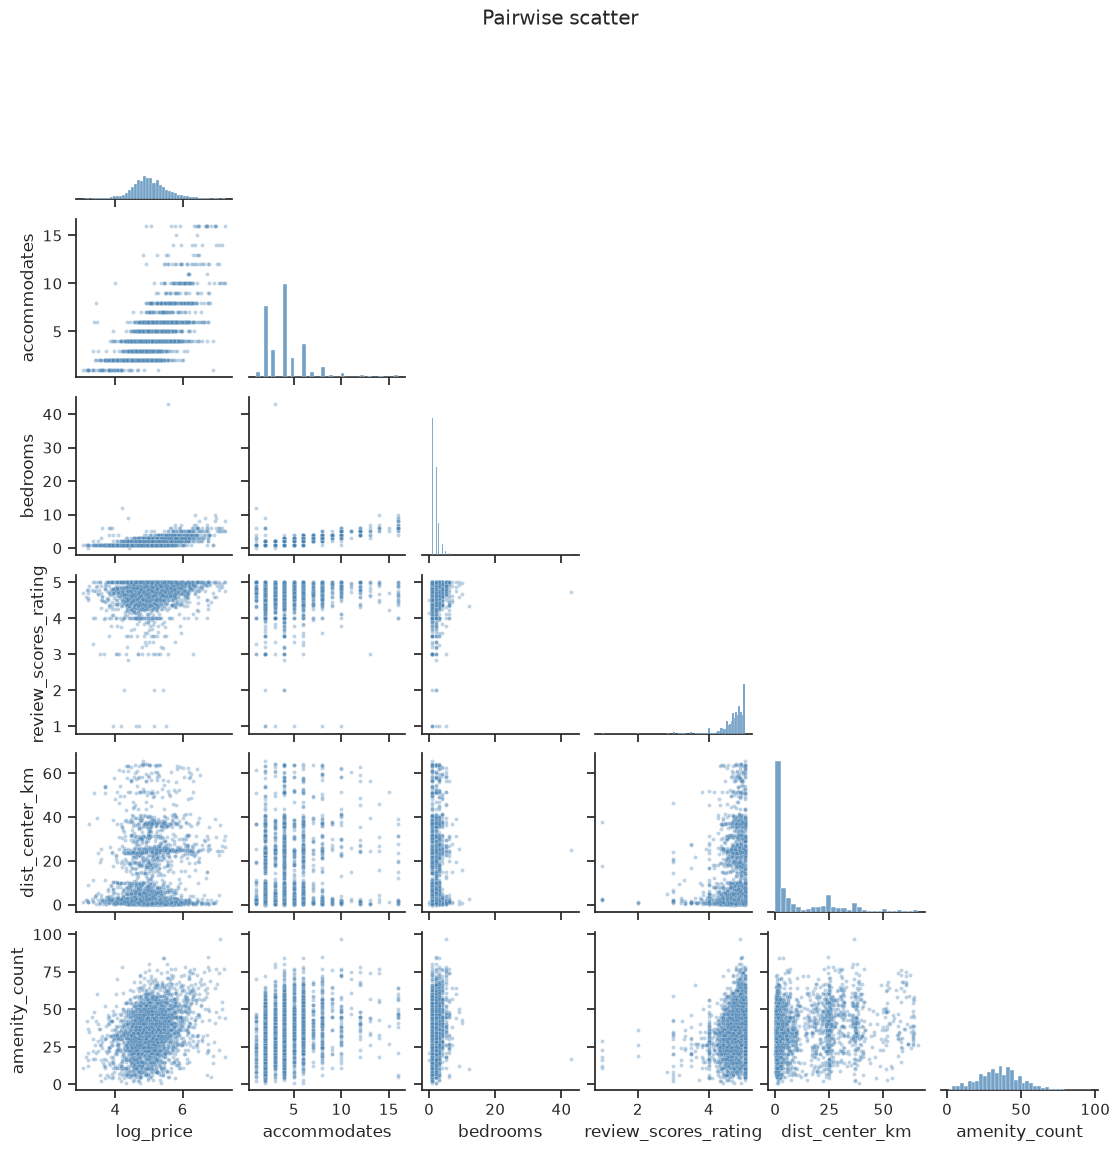

In [77]:
print(target_correlation(listings, hedonic_numeric, "log_price").to_string())
print(target_correlation(listings, hedonic_numeric + ["log_price"], "booked_share").to_string())
corr_hedonic = plot_correlation(listings, hedonic_numeric)
print(top_pairs(corr_hedonic, 10).to_string(index=False))
print("variance inflation factor, full feature set")
print(vif_table(listings, hedonic_numeric).to_string(index=False))
hedonic_reduced = [c for c in hedonic_numeric if c not in ["review_scores_value", "review_scores_location", "latitude", "longitude"]]
print("variance inflation factor without review_scores_value, review_scores_location, latitude and longitude")
print(vif_table(listings, hedonic_reduced).to_string(index=False))
plot_pairs(listings, ["log_price", "accommodates", "bedrooms", "review_scores_rating", "dist_center_km", "amenity_count"])

### Review models
* inputs: recent Lisbon Airbnb review texts, english looking texts kept by a stop word count
* keyword aspects and sentence embeddings work on the text itself, so the exploration covers volume, length and the language filter

In [78]:
# reviews with cleaned lower case text, its length and the english filter flag
def load_reviews(path):
    frame = pd.read_parquet(path)
    frame["date"] = pd.to_datetime(frame["date"])
    frame["text"] = frame["comments"].str.replace(r"<br\s*/?>", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
    frame["length"] = frame["text"].str.len()
    frame["english"] = frame["text"].str.count(r"\b(?:the|and|was|were|very|our|we|it|with|for)\b") >= 3
    return frame

In [79]:
# reviews per month
def plot_reviews_by_month(frame):
    monthly = frame.groupby(frame["date"].dt.to_period("M")).size()
    plt.figure(figsize=(9, 3.2))
    plt.bar(monthly.index.to_timestamp(), monthly.values, width=20, color="steelblue", edgecolor="black", linewidth=0.3)
    plt.ylabel("reviews")
    plt.title("Reviews by month")
    plt.show()

reviews 67956 from 2025-01-01 to 2026-07-01, listings 14028
english looking share 0.466, median length 206 characters


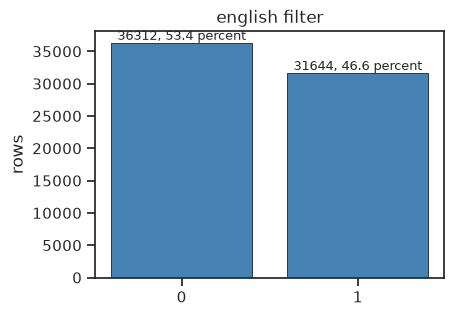

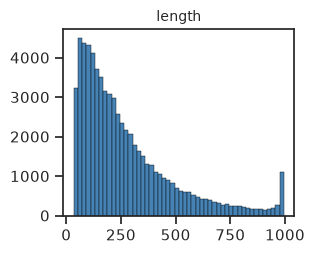

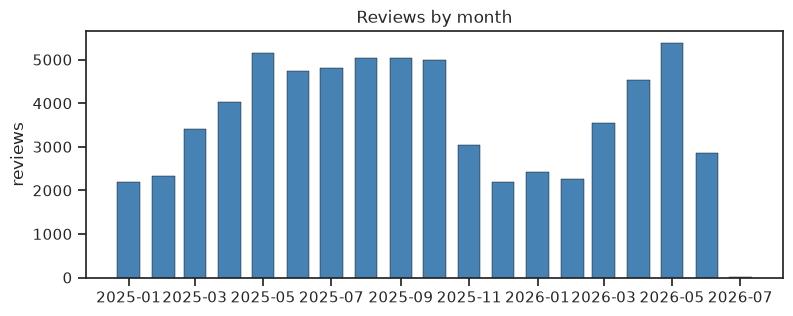

In [80]:
reviews = load_reviews(REVIEWS_PATH)
print("reviews " + str(len(reviews)) + " from " + str(reviews["date"].min().date()) + " to " + str(reviews["date"].max().date()) + ", listings " + str(reviews["listing_id"].nunique()))
print("english looking share " + str(round(float(reviews["english"].mean()), 3)) + ", median length " + str(int(reviews["length"].median())) + " characters")
plot_target_bar(reviews["english"].astype(int), "english filter")
plot_histograms(reviews, ["length"], ncols=1, bins=50)
plot_reviews_by_month(reviews)